# Milestone 3 - Modelação e Avaliação (Objetivo 3)

Neste notebook é realizada uma análise de clustering com o objetivo de identificar e caracterizar perfis distintos de colaboradores com base nas variáveis relevantes do dataset IBM HR Analytics Employee Attrition & Performance.

Esta etapa enquadra-se nas fases de *Modelling* e *Evaluation* da metodologia CRISP-DM, complementando a modelação supervisionada desenvolvida nos objetivos anteriores ao permitir a identificação de padrões latentes e estruturas internas nos dados.

Ao contrário dos modelos supervisionados, esta abordagem não utiliza a variável alvo (*Attrition*) no processo de aprendizagem, focando-se na segmentação dos colaboradores com base nas suas características. No entanto, esta variável é posteriormente utilizada para analisar a relação entre os clusters identificados e o risco de saída.

---

## Estrutura da Análise

Foram aplicados e comparados diferentes algoritmos de clustering:

- **Baseline:** K-Means  
- **Candidato 1:** K-Means Otimizado
- **Candidato 2:** DBSCAN  
- **Candidato 3:** Gaussian Mixture Models (GMM)  
- **Candidato 4:** Agrupamento Hierárquico  
- **Candidato 5:** OPTICS  
- **Candidato 6:** MiniBatch K-Means  

---

## Metodologia

A análise segue os seguintes passos principais:

- Preparação e normalização dos dados;
- Aplicação dos algoritmos no conjunto de treino;
- Avaliação da robustez através da comparação treino vs. teste;
- Seleção do modelo com melhor desempenho global;
- **Otimização de parâmetros (tuning)** do modelo selecionado;
- Análise da coesão e separação dos clusters;
- Caracterização estatística dos agrupamentos;
- Tradução dos clusters em **segmentos de negócio**;
- Análise exploratória da relação entre clusters e *Attrition*.

---

## Métricas de Avaliação

A qualidade dos modelos é avaliada com base em métricas internas:

- **Silhouette Score** → mede coesão e separação dos clusters (quanto maior, melhor);  
- **Davies-Bouldin Index** → avalia sobreposição entre clusters (quanto menor, melhor);  
- **Calinski-Harabasz Index** → mede separação global e compacidade (quanto maior, melhor).

Adicionalmente, é considerada a **estabilidade entre treino e teste**, garantindo que os padrões identificados são consistentes e generalizáveis.

---

## Objetivo Final

Selecionar o modelo que melhor segmenta os colaboradores, equilibrando qualidade estatística, robustez e interpretabilidade, e utilizá-lo para:

- Identificar perfis distintos de colaboradores;
- Apoiar decisões de gestão de recursos humanos;
- Detectar segmentos com maior propensão ao *attrition*;
- Suportar estratégias de retenção mais direcionadas.

---

**Autores:** Luís Figueira, Martim Ferreira e Mateus Afonso

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)

import warnings
warnings.filterwarnings('ignore')
print('Bibliotecas importadas com sucesso.')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Bibliotecas importadas com sucesso.


## 2. Carregamento dos Datasets

In [2]:


# Dataset completo — usado apenas para estratificação do split
url_full = 'https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv'
df_full  = pd.read_csv(url_full)

# Colunas a excluir — originais categóricas e target
cols_excluir = ["Attrition", "BusinessTravel", "Department", "EducationField",
                "Gender", "JobRole", "MaritalStatus", "OverTime", "Attrition_bin"]

X = df_full.drop(columns=cols_excluir)

# Autores: Figueira, L., Afonso, M. e Ferreira, M.

## 3. Divisão Treino / Teste (80/20)

> O `StandardScaler` faz `fit` apenas no treino para evitar *data leakage*.

In [3]:
X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print('Divisao treino/teste (80/20):')
print(f'  Treino: {X_train.shape[0]} amostras  ({X_train.shape[0]/X.shape[0]*100:.0f}%)')
print(f'  Teste:  {X_test.shape[0]} amostras  ({X_test.shape[0]/X.shape[0]*100:.0f}%)')
print(f'\n  Proporcao Attrition no treino: {df_full.loc[X_train.index, "Attrition_bin"].mean()*100:.1f}%')
print(f'  Proporcao Attrition no teste:  {df_full.loc[X_test.index, "Attrition_bin"].mean()*100:.1f}%')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Divisao treino/teste (80/20):
  Treino: 1176 amostras  (80%)
  Teste:  294 amostras  (20%)

  Proporcao Attrition no treino: 16.8%
  Proporcao Attrition no teste:  13.3%


## 4. Normalização

O `StandardScaler` é ajustado (`.fit_transform`) apenas no treino. No teste aplica-se apenas `.transform` com os parâmetros já aprendidos - sem *data leakage*.

In [4]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler aplicado (fit no treino, transform no teste).')
print(f'  Media treino:  {X_train_scaled.mean():.4f}  (deve ser ~0)')
print(f'  Std   treino:  {X_train_scaled.std():.4f}  (deve ser ~1)')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

StandardScaler aplicado (fit no treino, transform no teste).
  Media treino:  -0.0000  (deve ser ~0)
  Std   treino:  1.0000  (deve ser ~1)


In [5]:
def plot_profile_heatmap(X_df, clusters, modelo_nome, cols_perfil=None, figsize_mult=1.0):
    """Heatmap de perfil por cluster vs média populacional.
    Cores baseadas em z-score (comparabilidade visual), anotações com valores reais.
    """
    if cols_perfil is None:
        cols_perfil = X_df.select_dtypes(include='number').columns.tolist()
    df_tmp = X_df[cols_perfil].copy()
    df_tmp['Cluster'] = clusters
    perfil = df_tmp.groupby('Cluster')[cols_perfil].mean()

    # media populacional como referencia
    pop_mean = X_df[cols_perfil].mean()
    perfil_completo = pd.concat([
        perfil,
        pd.DataFrame(pop_mean, columns=['Population Mean']).T
    ])

    # z-score apenas para as cores
    from scipy.stats import zscore as scipy_zscore
    perfil_viz = perfil_completo.apply(scipy_zscore, axis=0)

    n_c = len(perfil_completo)
    n_v = len(cols_perfil)
    fig_h = max(6, n_v * 0.38 * figsize_mult)
    fig_w = max(10, n_c * 1.3 * figsize_mult)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # heatmap sem anotações automáticas
    sns.heatmap(
        perfil_viz.T,
        annot=False,
        cmap='RdYlGn', center=0,
        linewidths=0.3, linecolor='white',
        cbar_kws={'label': 'Z-score (escala de cor)'},
        ax=ax
    )

    # anotações manuais com valores reais
    annot_size = max(5, min(8, int(120 / n_v)))
    for i, col in enumerate(cols_perfil):
        for j, idx in enumerate(perfil_completo.index):
            val = perfil_completo.loc[idx, col]
            ax.text(j + 0.5, i + 0.5,
                    f'{val:.2f}',
                    ha='center', va='center',
                    fontsize=annot_size, color='black')

    ax.set_title(f'Perfil por Cluster vs Média Populacional — {modelo_nome}', fontsize=13, pad=12)
    ax.set_xlabel('Cluster', fontsize=11)
    ax.set_ylabel('Variável', fontsize=11)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0, labelsize=max(6, min(9, int(130 / n_v))))
    plt.tight_layout()
    fname = 'perfil_' + modelo_nome.replace(' ', '_').lower() + '.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    return perfil_completo
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

## 5. Baseline - K-Means k=4

Recalculado com o **mesmo split 80/20 estratificado** para ser diretamente comparável com os candidatos.

> Parâmetros totalmente default — sem `random_state` nem `n_init`.

In [6]:
kmeans_base         = KMeans(n_clusters=4)
clusters_train_base = kmeans_base.fit_predict(X_train_scaled)
clusters_test_base  = kmeans_base.predict(X_test_scaled)

sil_train_base = silhouette_score(X_train_scaled, clusters_train_base)
db_train_base  = davies_bouldin_score(X_train_scaled, clusters_train_base)
ch_train_base  = calinski_harabasz_score(X_train_scaled, clusters_train_base)

sil_test_base  = silhouette_score(X_test_scaled, clusters_test_base)
db_test_base   = davies_bouldin_score(X_test_scaled, clusters_test_base)
ch_test_base   = calinski_harabasz_score(X_test_scaled, clusters_test_base)

print('===== BASELINE — K-Means k=4 =====')
print(f'{"Metrica":<25} {"Treino":>10} {"Teste":>10}')
print(f'{"-"*45}')
print(f'{"Silhouette Score":<25} {sil_train_base:>10.4f} {sil_test_base:>10.4f}')
print(f'{"Davies-Bouldin":<25} {db_train_base:>10.4f} {db_test_base:>10.4f}')
print(f'{"Calinski-Harabasz":<25} {ch_train_base:>10.2f} {ch_test_base:>10.2f}')
print(f'\n  Meta Silhouette > 0.50: {"ATINGIDA" if sil_test_base > 0.50 else "NAO ATINGIDA"}')
print(f'\nDistribuicao clusters — Treino:')
print(pd.Series(clusters_train_base).value_counts().sort_index().to_string())
print(f'\nDistribuicao clusters — Teste:')
print(pd.Series(clusters_test_base).value_counts().sort_index().to_string())

===== BASELINE — K-Means k=4 =====
Metrica                       Treino      Teste
---------------------------------------------
Silhouette Score              0.0926     0.0842
Davies-Bouldin                2.5409     2.5080
Calinski-Harabasz              83.71      20.97

  Meta Silhouette > 0.50: NAO ATINGIDA

Distribuicao clusters — Treino:
0    202
1     46
2    320
3    608

Distribuicao clusters — Teste:
0     57
1     12
2     74
3    151


### 5.1 Silhouette Plot - Baseline (Treino)

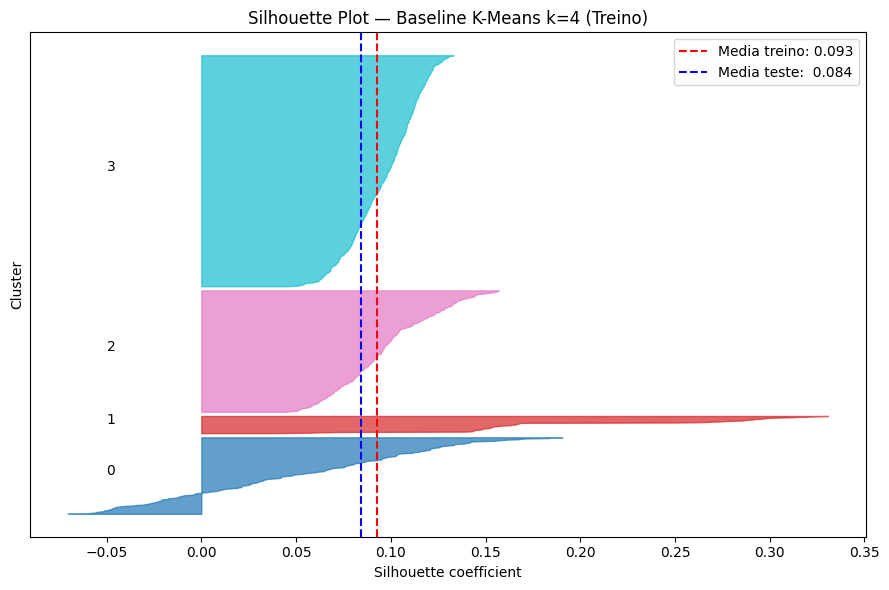

In [7]:
sample_sil_base = silhouette_samples(X_train_scaled, clusters_train_base)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower   = 10
colors_b  = plt.cm.tab10(np.linspace(0, 1, 4))

for i in range(4):
    vals    = sample_sil_base[clusters_train_base == i]
    vals.sort()
    size    = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors_b[i], edgecolor=colors_b[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_base, color='red',  linestyle='--', linewidth=1.5, label=f'Media treino: {sil_train_base:.3f}')
ax.axvline(sil_test_base,  color='blue', linestyle='--', linewidth=1.5, label=f'Media teste:  {sil_test_base:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — Baseline K-Means k=4 (Treino)')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('silhouette_plot_baseline_split.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Visualização PCA - Baseline Treino vs. Teste

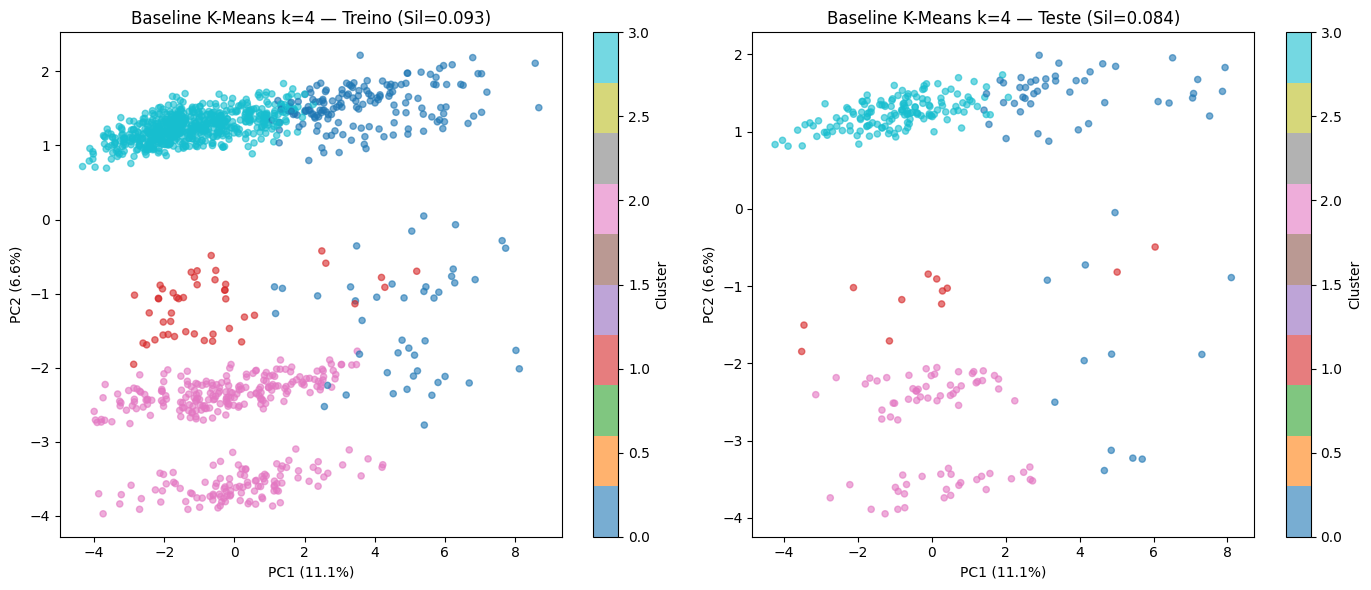

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA
pca_base = PCA(n_components=2)
X_train_pca_base = pca_base.fit_transform(X_train_scaled)
X_test_pca_base = pca_base.transform(X_test_scaled)
var_base = pca_base.explained_variance_ratio_

# Figura
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Treino
sc1 = axes[0].scatter(
    X_train_pca_base[:, 0],
    X_train_pca_base[:, 1],
    c=clusters_train_base,
    cmap='tab10',
    alpha=0.6,
    s=20
)
axes[0].set_title(f'Baseline K-Means k=4 — Treino (Sil={sil_train_base:.3f})')
axes[0].set_xlabel(f'PC1 ({var_base[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_base[1]*100:.1f}%)')
fig.colorbar(sc1, ax=axes[0], label='Cluster')

# Teste
sc2 = axes[1].scatter(
    X_test_pca_base[:, 0],
    X_test_pca_base[:, 1],
    c=clusters_test_base,
    cmap='tab10',
    alpha=0.6,
    s=20
)
axes[1].set_title(f'Baseline K-Means k=4 — Teste (Sil={sil_test_base:.3f})')
axes[1].set_xlabel(f'PC1 ({var_base[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_base[1]*100:.1f}%)')
fig.colorbar(sc2, ax=axes[1], label='Cluster')

fig.tight_layout()

# Guarda primeiro
fig.savefig("pca_baseline_treino_teste.png", dpi=120, bbox_inches="tight")

# Mostra
plt.show()

# Fecha para libertar memória
plt.close(fig)

### 5.3 Distribuição dos Clusters - Baseline Treino vs. Teste

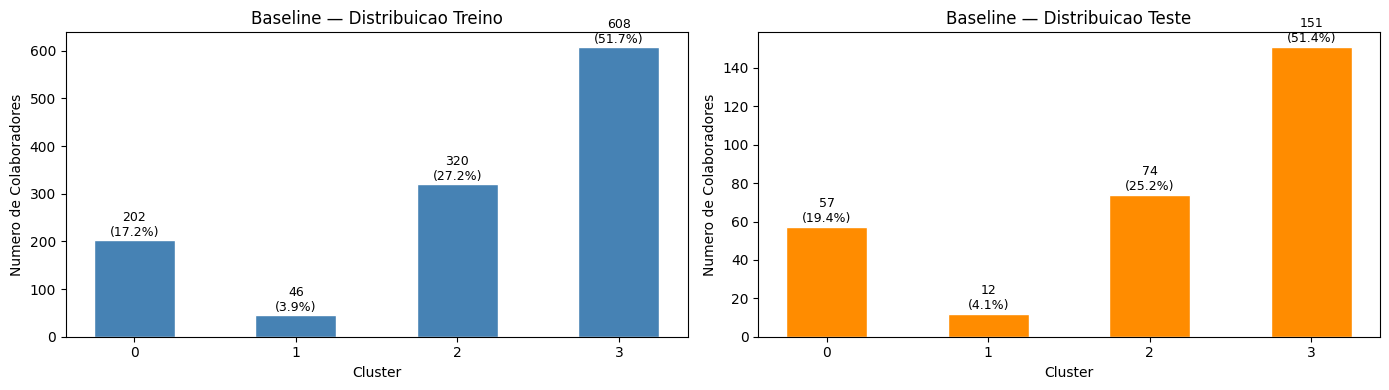

In [9]:
contagem_base_train = pd.Series(clusters_train_base).value_counts().sort_index()
contagem_base_test  = pd.Series(clusters_test_base).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars1 = axes[0].bar(contagem_base_train.index, contagem_base_train.values,
                    color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars1, contagem_base_train.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}\n({val/len(clusters_train_base)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Numero de Colaboradores')
axes[0].set_title('Baseline — Distribuicao Treino')
axes[0].set_xticks(contagem_base_train.index)

bars2 = axes[1].bar(contagem_base_test.index, contagem_base_test.values,
                    color='darkorange', edgecolor='white', width=0.5)
for bar, val in zip(bars2, contagem_base_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(clusters_test_base)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero de Colaboradores')
axes[1].set_title('Baseline — Distribuicao Teste')
axes[1].set_xticks(contagem_base_test.index)

plt.tight_layout()
plt.savefig('distribuicao_baseline_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

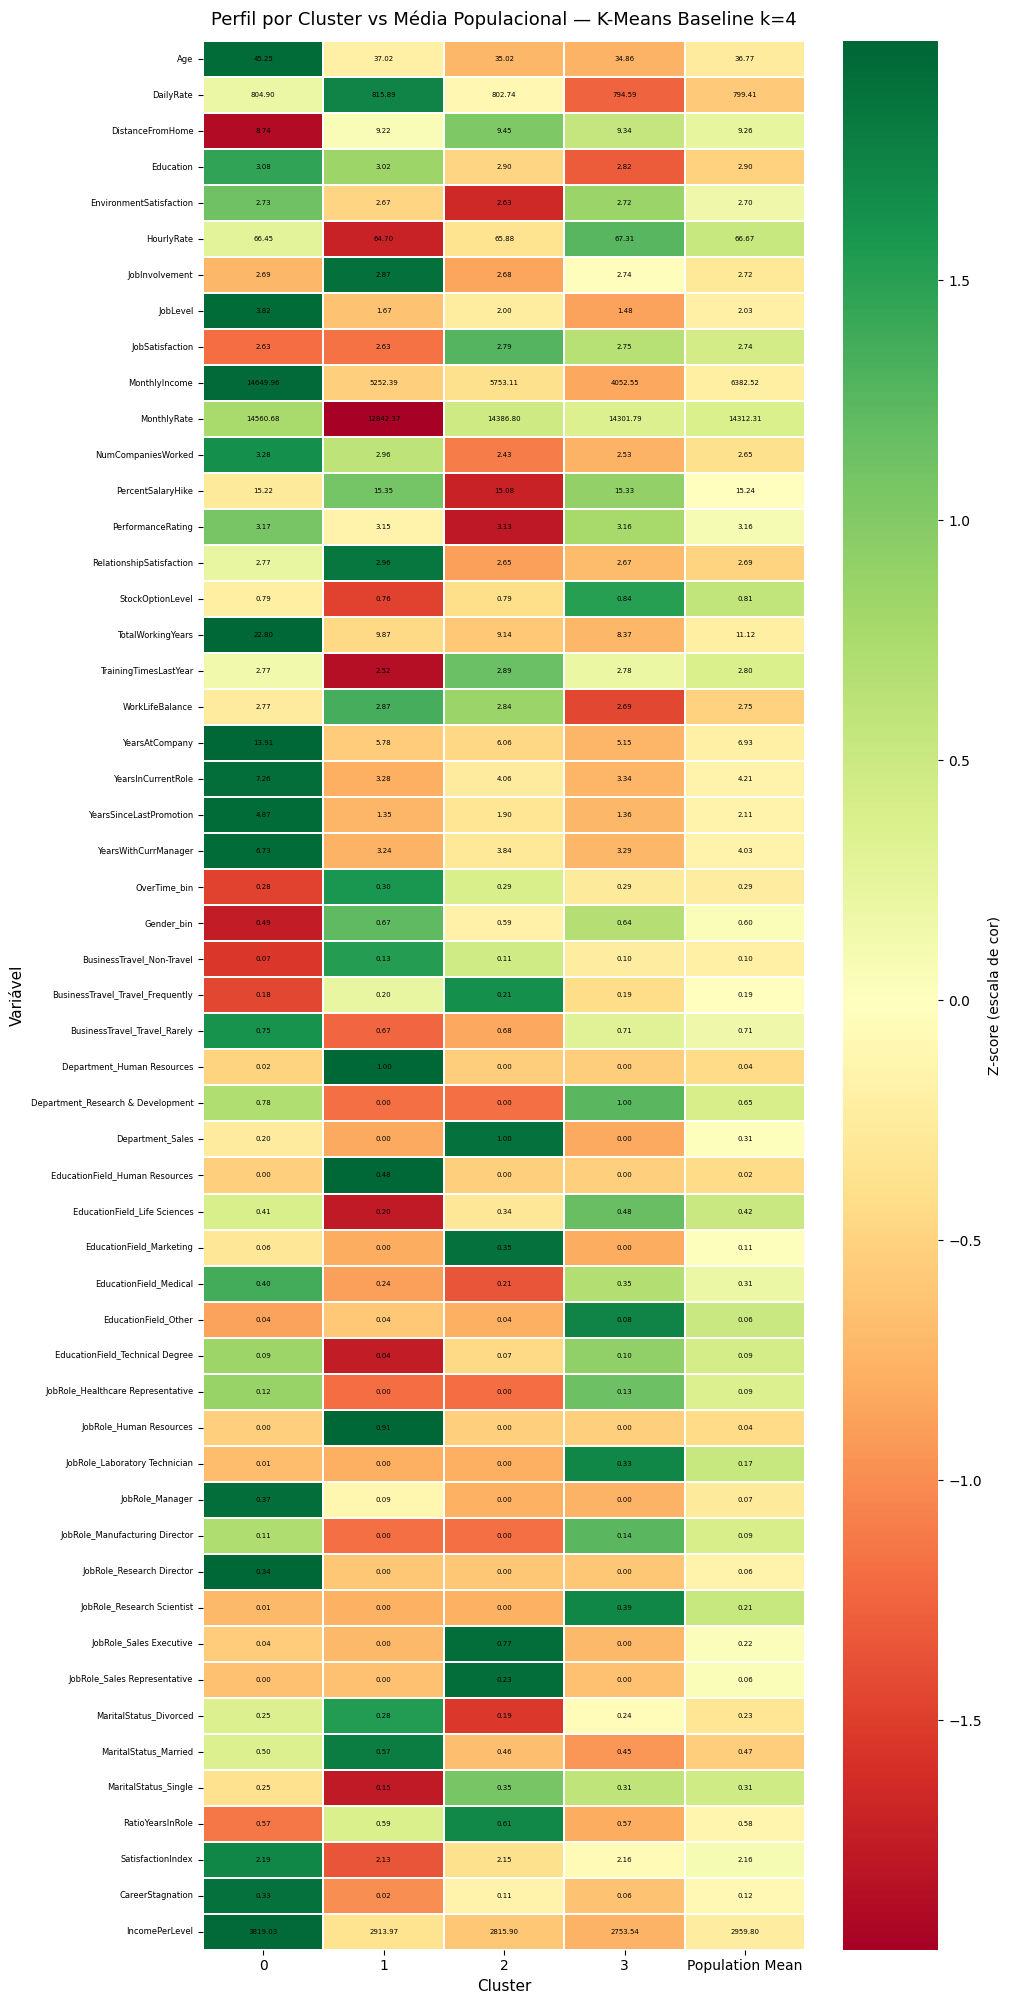

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,RatioYearsInRole,SatisfactionIndex,CareerStagnation,IncomePerLevel
0,45.252475,804.900990,8.737624,3.079208,2.727723,66.445545,2.693069,3.816832,2.628713,14649.955446,...,0.009901,0.044554,0.000000,0.247525,0.504950,0.247525,0.565259,2.193069,0.331683,3819.026485
1,37.021739,815.891304,9.217391,3.021739,2.673913,64.695652,2.869565,1.673913,2.630435,5252.391304,...,0.000000,0.000000,0.000000,0.282609,0.565217,0.152174,0.588369,2.130435,0.021739,2913.969203
2,35.025000,802.740625,9.453125,2.900000,2.634375,65.884375,2.684375,1.996875,2.790625,5753.109375,...,0.000000,0.765625,0.234375,0.190625,0.462500,0.346875,0.608872,2.150000,0.109375,2815.897135
3,34.860197,794.587171,9.335526,2.824013,2.718750,67.310855,2.740132,1.476974,2.750000,4052.552632,...,0.394737,0.000000,0.000000,0.235197,0.450658,0.314145,0.570156,2.156250,0.059211,2753.535910
Population Mean,36.774660,799.410714,9.260204,2.896259,2.695578,66.671769,2.721939,2.028061,2.735544,6382.523810,...,0.205782,0.215986,0.063776,0.227041,0.467687,0.305272,0.580563,2.159864,0.118197,2959.798342


In [10]:
plot_profile_heatmap(X_train, clusters_train_base, 'K-Means Baseline k=4')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

## 6. Candidato 1 - K-Means Otimizado

Pesquisa do k ótimo por Silhouette Score no conjunto de treino, seguida de treino do modelo final e avaliação no teste.


### 6.1 Pesquisa do k ótimo - Elbow + Silhouette (Treino)

In [11]:
melhor_k = 4
print(f'k fixo: {melhor_k}')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

k fixo: 4


In [12]:
# Gráfico de pesquisa removido — k fixo em 4
print('k=4 definido diretamente, sem pesquisa.')


k=4 definido diretamente, sem pesquisa.


### 6.2 Treino do Modelo Final e Métricas Treino vs Teste

In [13]:
kmeans_final      = KMeans(n_clusters=melhor_k)
clusters_train_km = kmeans_final.fit_predict(X_train_scaled)
clusters_test_km  = kmeans_final.predict(X_test_scaled)

sil_train_km = silhouette_score(X_train_scaled, clusters_train_km)
db_train_km  = davies_bouldin_score(X_train_scaled, clusters_train_km)
ch_train_km  = calinski_harabasz_score(X_train_scaled, clusters_train_km)

sil_test_km  = silhouette_score(X_test_scaled, clusters_test_km)
db_test_km   = davies_bouldin_score(X_test_scaled, clusters_test_km)
ch_test_km   = calinski_harabasz_score(X_test_scaled, clusters_test_km)

print(f'===== K-MEANS k={melhor_k} — TREINO vs. TESTE =====')
print(f'{"Metrica":<25} {"Treino":>10} {"Teste":>10} {"Diferenca":>12}')
print(f'{"-"*57}')
print(f'{"Silhouette Score":<25} {sil_train_km:>10.4f} {sil_test_km:>10.4f} {abs(sil_train_km-sil_test_km):>12.4f}')
print(f'{"Davies-Bouldin":<25} {db_train_km:>10.4f} {db_test_km:>10.4f} {abs(db_train_km-db_test_km):>12.4f}')
print(f'{"Calinski-Harabasz":<25} {ch_train_km:>10.2f} {ch_test_km:>10.2f} {abs(ch_train_km-ch_test_km):>12.2f}')
print(f'\n  Meta Silhouette > 0.50 (Treino): {"ATINGIDA" if sil_train_km > 0.50 else "NAO ATINGIDA"}')
print(f'  Meta Silhouette > 0.50 (Teste):  {"ATINGIDA" if sil_test_km  > 0.50 else "NAO ATINGIDA"}')
print(f'\nDistribuicao clusters — Treino:')
print(pd.Series(clusters_train_km).value_counts().sort_index().to_string())
print(f'\nDistribuicao clusters — Teste:')
print(pd.Series(clusters_test_km).value_counts().sort_index().to_string())

===== K-MEANS k=4 — TREINO vs. TESTE =====
Metrica                       Treino      Teste    Diferenca
---------------------------------------------------------
Silhouette Score              0.0923     0.0842       0.0081
Davies-Bouldin                2.5427     2.5080       0.0348
Calinski-Harabasz              83.72      20.97        62.75

  Meta Silhouette > 0.50 (Treino): NAO ATINGIDA
  Meta Silhouette > 0.50 (Teste):  NAO ATINGIDA

Distribuicao clusters — Treino:
0    603
1    207
2    320
3     46

Distribuicao clusters — Teste:
0    151
1     57
2     74
3     12


### 6.3 Silhouette Plot - K-Means Otimizado (Treino)

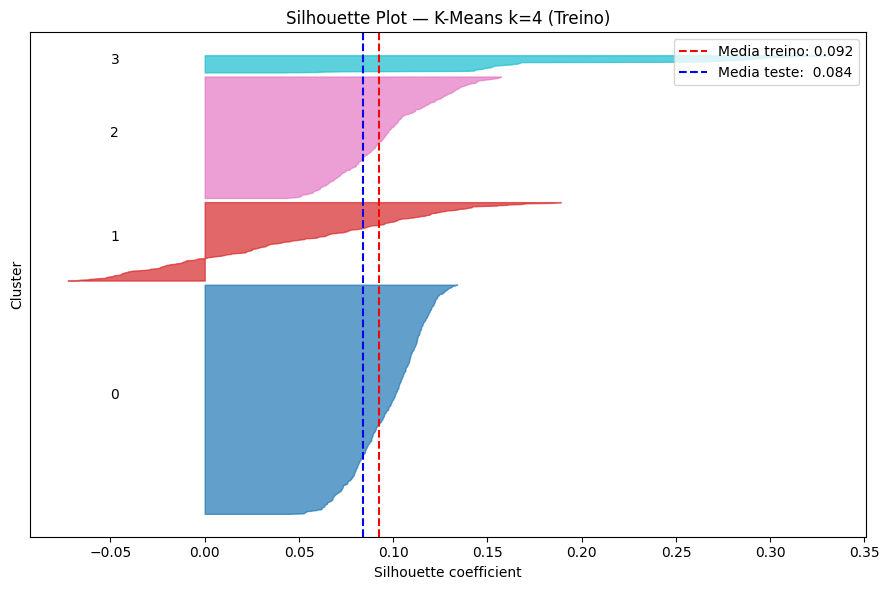

In [14]:
sample_sil_km = silhouette_samples(X_train_scaled, clusters_train_km)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower  = 10
colors   = plt.cm.tab10(np.linspace(0, 1, melhor_k))

for i in range(melhor_k):
    vals    = sample_sil_km[clusters_train_km == i]
    vals.sort()
    size    = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_km, color='red',  linestyle='--', linewidth=1.5, label=f'Media treino: {sil_train_km:.3f}')
ax.axvline(sil_test_km,  color='blue', linestyle='--', linewidth=1.5, label=f'Media teste:  {sil_test_km:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — K-Means k={melhor_k} (Treino)')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('silhouette_plot_kmeans_otimizado.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Visualização PCA - K-Means Treino vs. Teste

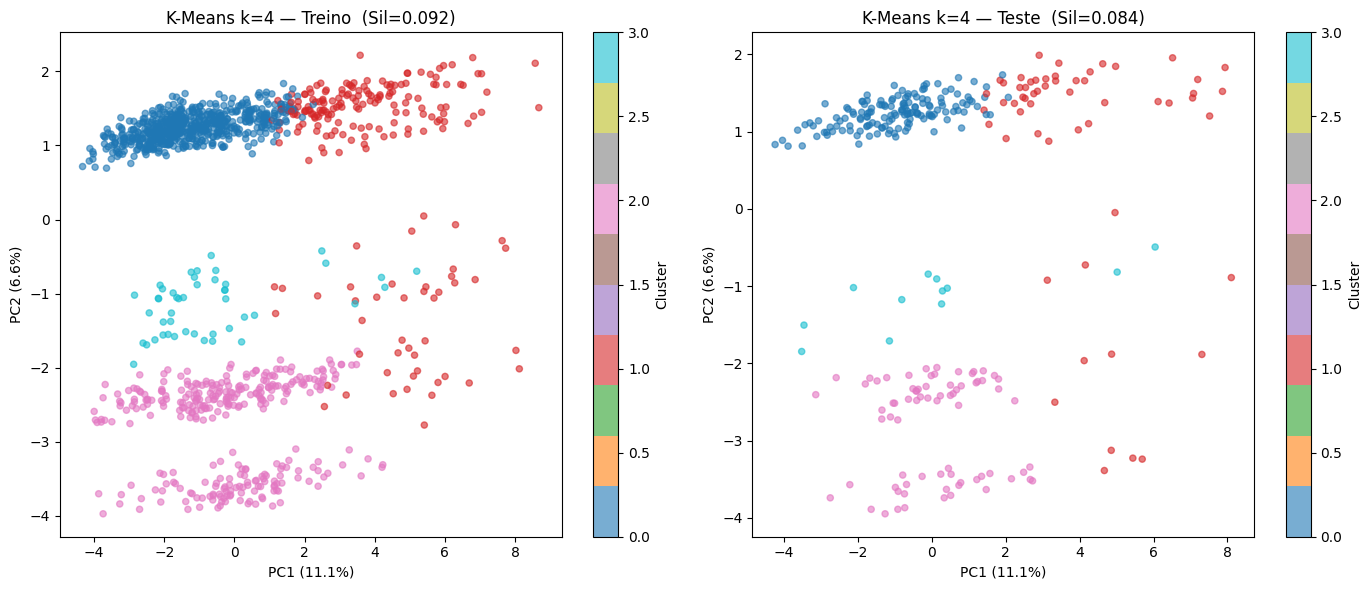

In [15]:
pca         = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
variancia   = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=clusters_train_km, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title(f'K-Means k={melhor_k} — Treino  (Sil={sil_train_km:.3f})')
axes[0].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                      c=clusters_test_km, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title(f'K-Means k={melhor_k} — Teste  (Sil={sil_test_km:.3f})')
axes[1].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('pca_kmeans_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Distribuição dos Clusters - K-Means Treino vs. Teste

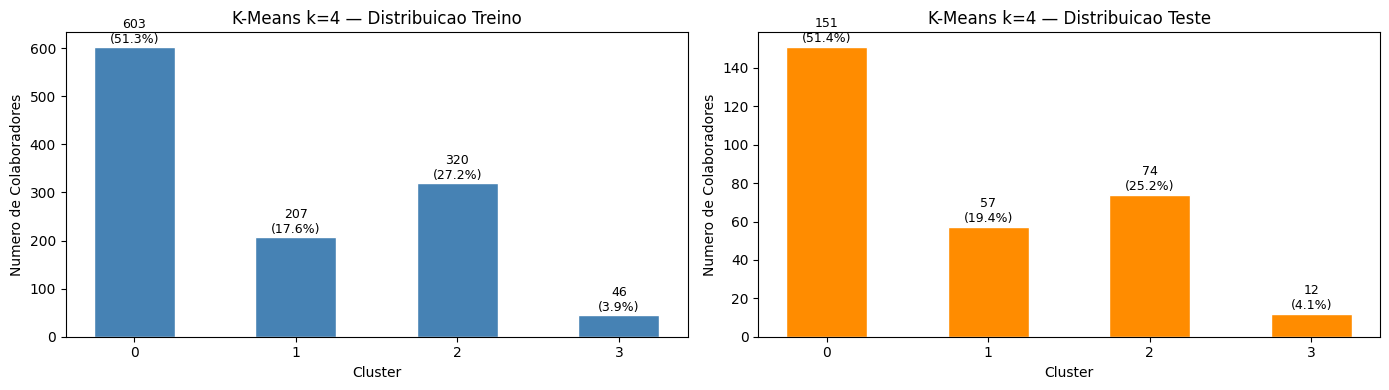

In [16]:
contagem_km_train = pd.Series(clusters_train_km).value_counts().sort_index()
contagem_km_test  = pd.Series(clusters_test_km).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars1 = axes[0].bar(contagem_km_train.index, contagem_km_train.values,
                    color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars1, contagem_km_train.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}\n({val/len(clusters_train_km)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Numero de Colaboradores')
axes[0].set_title(f'K-Means k={melhor_k} — Distribuicao Treino')
axes[0].set_xticks(contagem_km_train.index)

bars2 = axes[1].bar(contagem_km_test.index, contagem_km_test.values,
                    color='darkorange', edgecolor='white', width=0.5)
for bar, val in zip(bars2, contagem_km_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(clusters_test_km)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero de Colaboradores')
axes[1].set_title(f'K-Means k={melhor_k} — Distribuicao Teste')
axes[1].set_xticks(contagem_km_test.index)

plt.tight_layout()
plt.savefig('distribuicao_kmeans_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

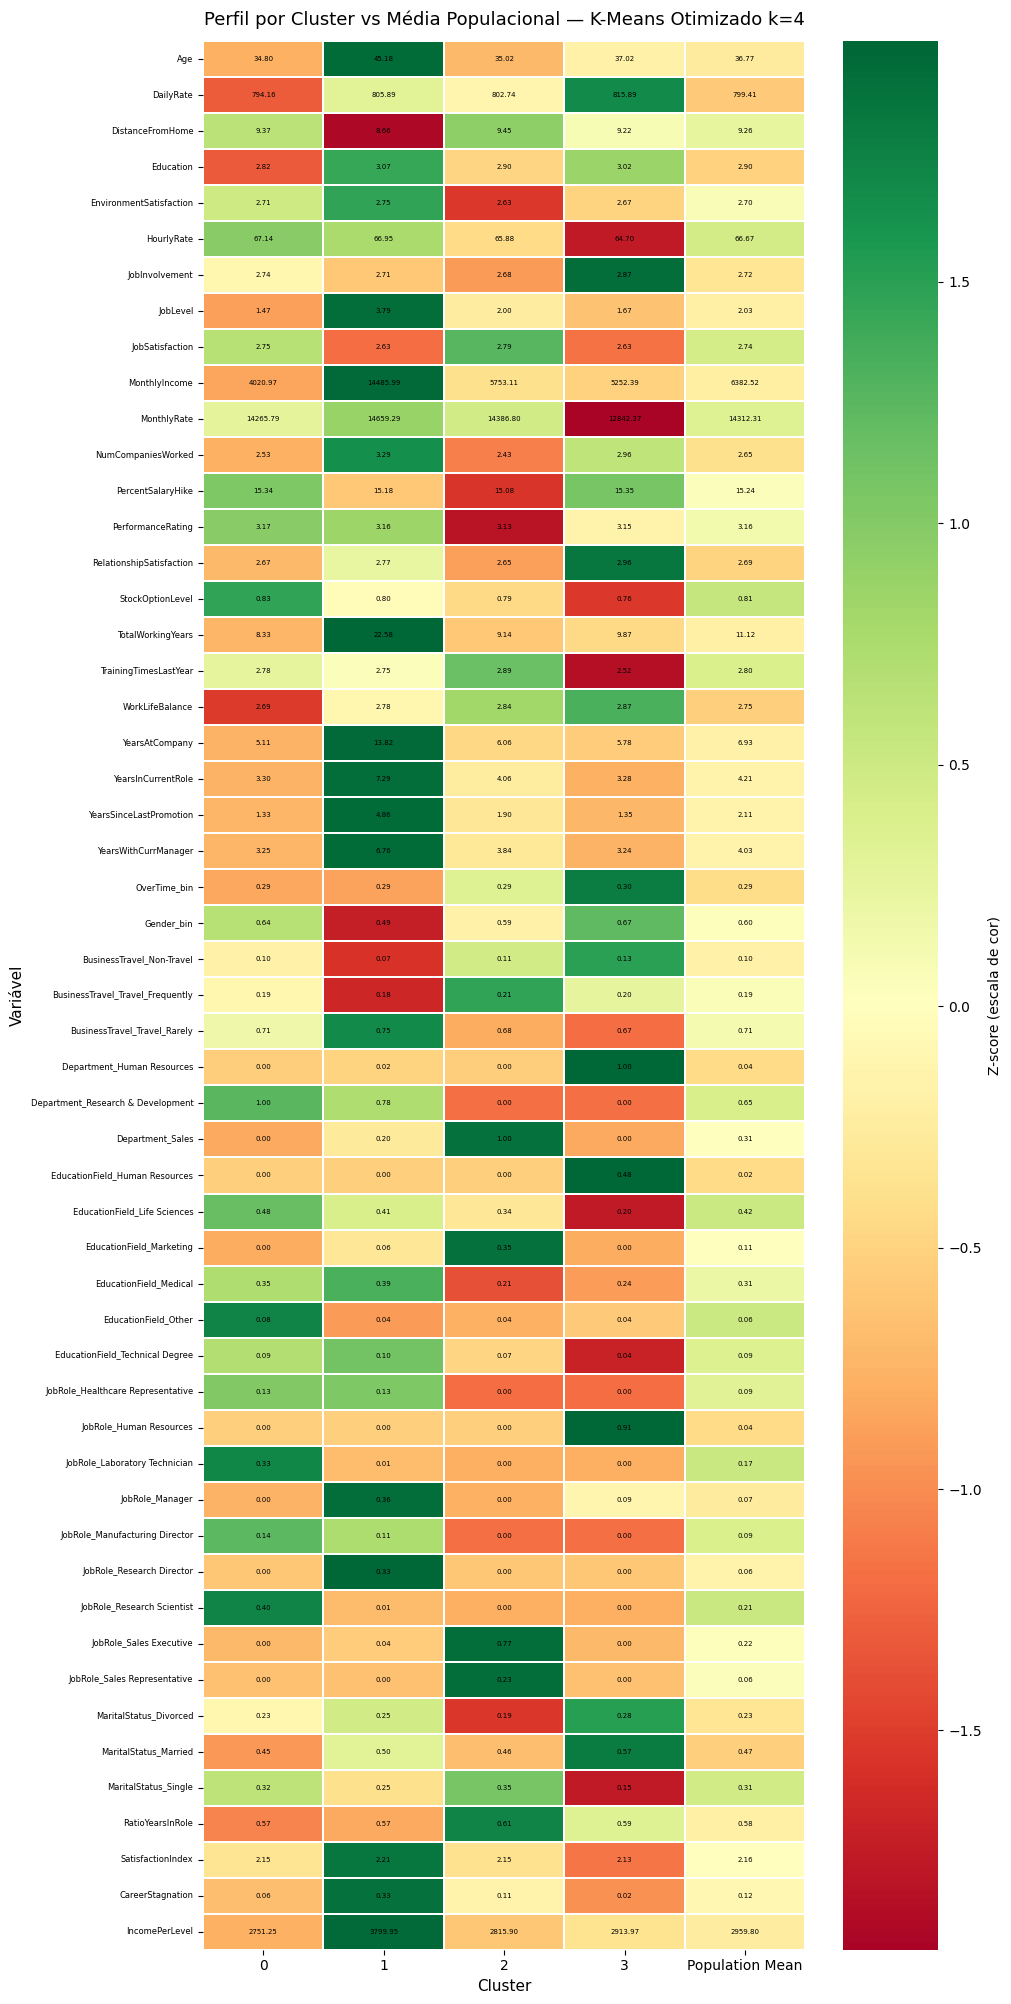

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,RatioYearsInRole,SatisfactionIndex,CareerStagnation,IncomePerLevel
0,34.797678,794.160862,9.368159,2.824212,2.711443,67.144279,2.736318,1.467662,2.751244,4020.966833,...,0.396352,0.000000,0.000000,0.233831,0.451078,0.315091,0.568081,2.150912,0.056385,2751.248480
1,45.183575,805.893720,8.657005,3.072464,2.748792,66.951691,2.705314,3.787440,2.628019,14485.990338,...,0.014493,0.043478,0.000000,0.251208,0.502415,0.246377,0.571424,2.207729,0.333333,3799.953382
2,35.025000,802.740625,9.453125,2.900000,2.634375,65.884375,2.684375,1.996875,2.790625,5753.109375,...,0.000000,0.765625,0.234375,0.190625,0.462500,0.346875,0.608872,2.150000,0.109375,2815.897135
3,37.021739,815.891304,9.217391,3.021739,2.673913,64.695652,2.869565,1.673913,2.630435,5252.391304,...,0.000000,0.000000,0.000000,0.282609,0.565217,0.152174,0.588369,2.130435,0.021739,2913.969203
Population Mean,36.774660,799.410714,9.260204,2.896259,2.695578,66.671769,2.721939,2.028061,2.735544,6382.523810,...,0.205782,0.215986,0.063776,0.227041,0.467687,0.305272,0.580563,2.159864,0.118197,2959.798342


In [17]:
plot_profile_heatmap(X_train, clusters_train_km, f'K-Means Otimizado k={melhor_k}')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

## 7. Candidato 2 - DBSCAN

Algoritmo baseado em densidade que não requer definir k à priori. Identifica automaticamente o número de clusters e marca pontos isolados como ruído.

### 7.1 K-distance Plot - Escolha do eps (Treino)

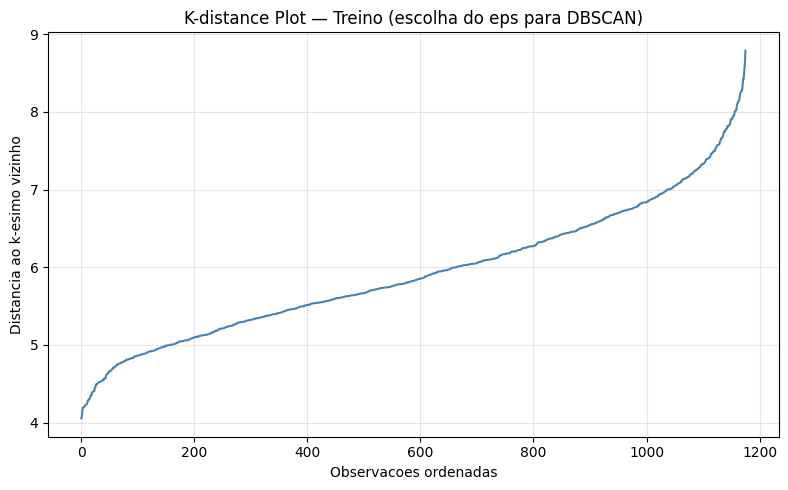

In [18]:
k_nn         = 3
nn           = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X_train_scaled)
distances, _ = nn.kneighbors(X_train_scaled)
distances     = np.sort(distances[:, k_nn - 1])

plt.figure(figsize=(8, 5))
plt.plot(distances, color='steelblue')
plt.title('K-distance Plot — Treino (escolha do eps para DBSCAN)')
plt.xlabel('Observacoes ordenadas')
plt.ylabel('Distancia ao k-esimo vizinho')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdistance_treino.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Treino do DBSCAN e Métricas

In [19]:
eps_value         = 8.0
dbscan            = DBSCAN(eps=eps_value, min_samples=5)
clusters_train_db = dbscan.fit_predict(X_train_scaled)

n_clusters_db = len(set(clusters_train_db)) - (1 if -1 in clusters_train_db else 0)
noise_train   = np.sum(clusters_train_db == -1)
noise_pct     = noise_train / len(clusters_train_db) * 100

print(f'DBSCAN treino (eps={eps_value}, min_samples=5):')
print(f'  Clusters encontrados: {n_clusters_db}')
print(f'  Ruido:                {noise_train} pontos ({noise_pct:.1f}%)')
print(f'\nDistribuicao clusters treino:')
print(pd.Series(clusters_train_db).value_counts().sort_index().to_string())

mask_train_db = clusters_train_db != -1

if len(set(clusters_train_db[mask_train_db])) > 1:
    sil_train_db = silhouette_score(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
    db_train_db  = davies_bouldin_score(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
    ch_train_db  = calinski_harabasz_score(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
    print(f'\nMetricas TREINO (sem ruido):')
    print(f'  Silhouette Score:       {sil_train_db:.4f}')
    print(f'  Davies-Bouldin Index:   {db_train_db:.4f}')
    print(f'  Calinski-Harabasz:      {ch_train_db:.2f}')
else:
    print('\nClusters insuficientes para calcular metricas.')
    sil_train_db = db_train_db = ch_train_db = float('nan')

DBSCAN treino (eps=8.0, min_samples=5):
  Clusters encontrados: 3
  Ruido:                13 pontos (1.1%)

Distribuicao clusters treino:
-1      13
 0    1121
 1      18
 2      24

Metricas TREINO (sem ruido):
  Silhouette Score:       0.1708
  Davies-Bouldin Index:   1.5778
  Calinski-Harabasz:      34.39


### 7.3 Aplicação ao Teste via KNN

In [20]:
knn_db           = KNeighborsClassifier(n_neighbors=5)
knn_db.fit(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
clusters_test_db = knn_db.predict(X_test_scaled)

print('Distribuicao clusters teste (via KNN):')
print(pd.Series(clusters_test_db).value_counts().sort_index().to_string())

if len(set(clusters_test_db)) > 1:
    sil_test_db = silhouette_score(X_test_scaled, clusters_test_db)
    db_test_db  = davies_bouldin_score(X_test_scaled, clusters_test_db)
    ch_test_db  = calinski_harabasz_score(X_test_scaled, clusters_test_db)
else:
    sil_test_db = db_test_db = ch_test_db = float('nan')

print(f'\n===== DBSCAN — TREINO vs. TESTE =====')
print(f'{"Metrica":<25} {"Treino":>10} {"Teste":>10} {"Diferenca":>12}')
print(f'{"-"*57}')
print(f'{"Silhouette Score":<25} {sil_train_db:>10.4f} {sil_test_db:>10.4f} {abs(sil_train_db-sil_test_db):>12.4f}')
print(f'{"Davies-Bouldin":<25} {db_train_db:>10.4f} {db_test_db:>10.4f} {abs(db_train_db-db_test_db):>12.4f}')
print(f'{"Calinski-Harabasz":<25} {ch_train_db:>10.2f} {ch_test_db:>10.2f} {abs(ch_train_db-ch_test_db):>12.2f}')
print(f'\n  Nota: Teste via KNN (DBSCAN nao tem .predict() nativo)')
print(f'  Ruido no treino: {noise_pct:.1f}%  |  Ruido no teste: 0.0% (KNN)')

Distribuicao clusters teste (via KNN):
0    283
1      4
2      7

===== DBSCAN — TREINO vs. TESTE =====
Metrica                       Treino      Teste    Diferenca
---------------------------------------------------------
Silhouette Score              0.1708     0.1709       0.0001
Davies-Bouldin                1.5778     1.4790       0.0988
Calinski-Harabasz              34.39       8.51        25.89

  Nota: Teste via KNN (DBSCAN nao tem .predict() nativo)
  Ruido no treino: 1.1%  |  Ruido no teste: 0.0% (KNN)


### 7.4 Silhouette Plot - DBSCAN (Treino, sem ruído)

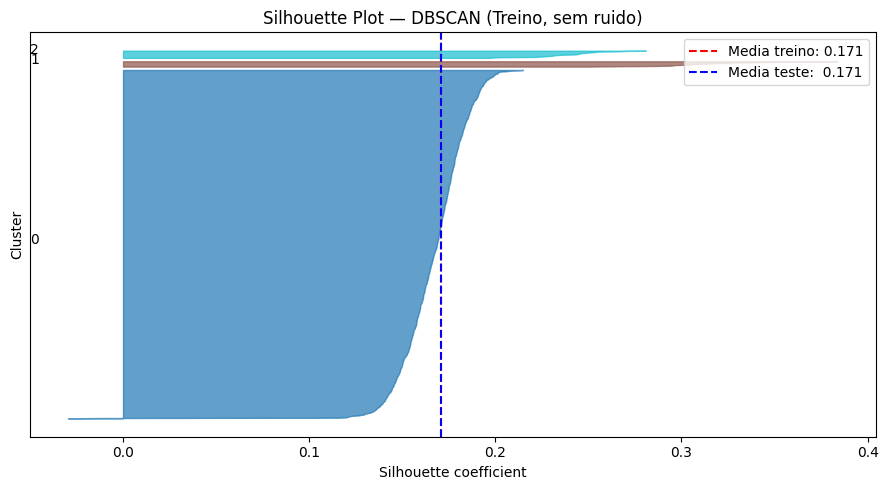

In [21]:
clusters_db_clean = clusters_train_db[mask_train_db]
X_db_clean        = X_train_scaled[mask_train_db]
sample_sil_db     = silhouette_samples(X_db_clean, clusters_db_clean)
unique_db         = sorted(set(clusters_db_clean))

fig, ax = plt.subplots(figsize=(9, 5))
y_lower   = 10
colors_d  = plt.cm.tab10(np.linspace(0, 1, len(unique_db)))

for idx, i in enumerate(unique_db):
    vals    = sample_sil_db[clusters_db_clean == i]
    vals.sort()
    size    = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors_d[idx], edgecolor=colors_d[idx], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_db, color='red',  linestyle='--', linewidth=1.5, label=f'Media treino: {sil_train_db:.3f}')
ax.axvline(sil_test_db,  color='blue', linestyle='--', linewidth=1.5, label=f'Media teste:  {sil_test_db:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — DBSCAN (Treino, sem ruido)')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('silhouette_plot_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Visualização PCA - DBSCAN Treino vs. Teste

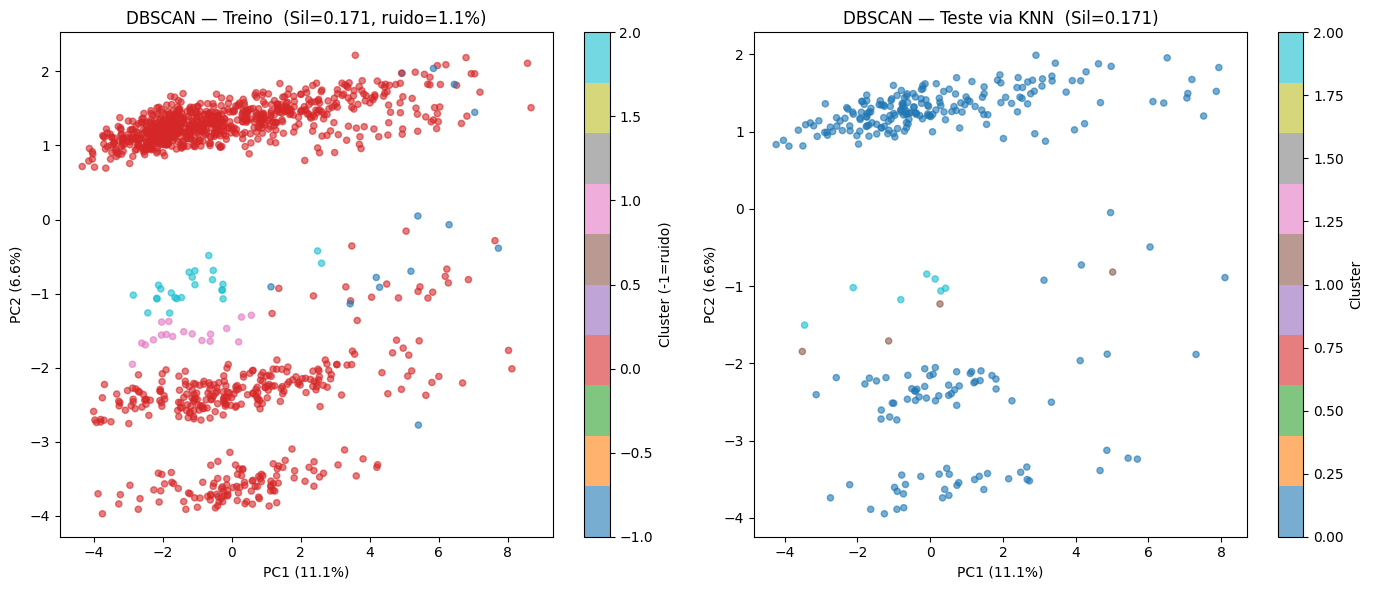

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=clusters_train_db, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title(f'DBSCAN — Treino  (Sil={sil_train_db:.3f}, ruido={noise_pct:.1f}%)')
axes[0].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster (-1=ruido)')

sc2 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                      c=clusters_test_db, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title(f'DBSCAN — Teste via KNN  (Sil={sil_test_db:.3f})')
axes[1].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('pca_dbscan_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Distribuição dos Clusters - DBSCAN Treino vs. Teste

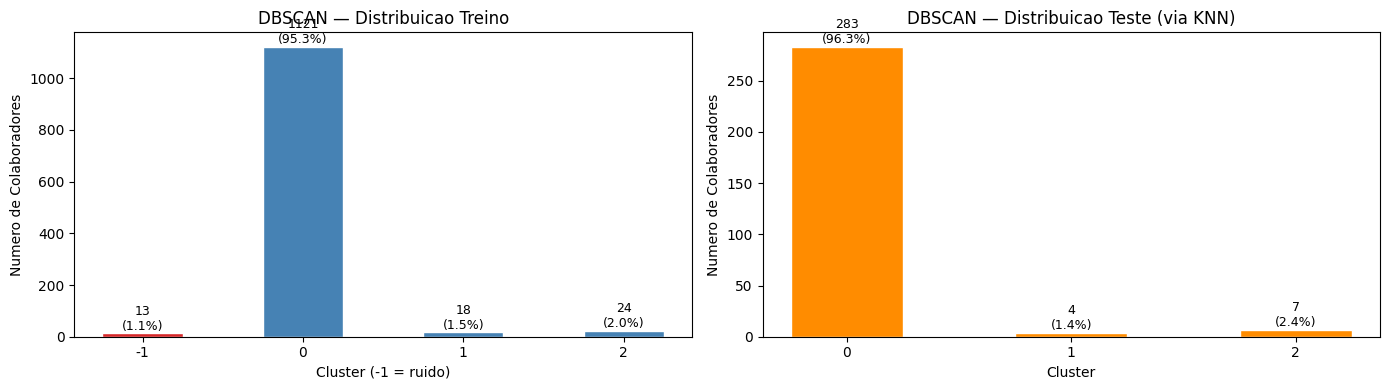

In [23]:
contagem_db_train = pd.Series(clusters_train_db).value_counts().sort_index()
contagem_db_test  = pd.Series(clusters_test_db).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors_dist = ['#d62728' if idx == -1 else 'steelblue'
               for idx in contagem_db_train.index]
bars1 = axes[0].bar(range(len(contagem_db_train)), contagem_db_train.values,
                    color=colors_dist, edgecolor='white', width=0.5)
for bar, val, lbl in zip(bars1, contagem_db_train.values, contagem_db_train.index):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}\n({val/len(clusters_train_db)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Cluster (-1 = ruido)')
axes[0].set_ylabel('Numero de Colaboradores')
axes[0].set_title('DBSCAN — Distribuicao Treino')
axes[0].set_xticks(range(len(contagem_db_train)))
axes[0].set_xticklabels(contagem_db_train.index)

bars2 = axes[1].bar(contagem_db_test.index, contagem_db_test.values,
                    color='darkorange', edgecolor='white', width=0.5)
for bar, val in zip(bars2, contagem_db_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(clusters_test_db)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero de Colaboradores')
axes[1].set_title('DBSCAN — Distribuicao Teste (via KNN)')
axes[1].set_xticks(contagem_db_test.index)

plt.tight_layout()
plt.savefig('distribuicao_dbscan_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

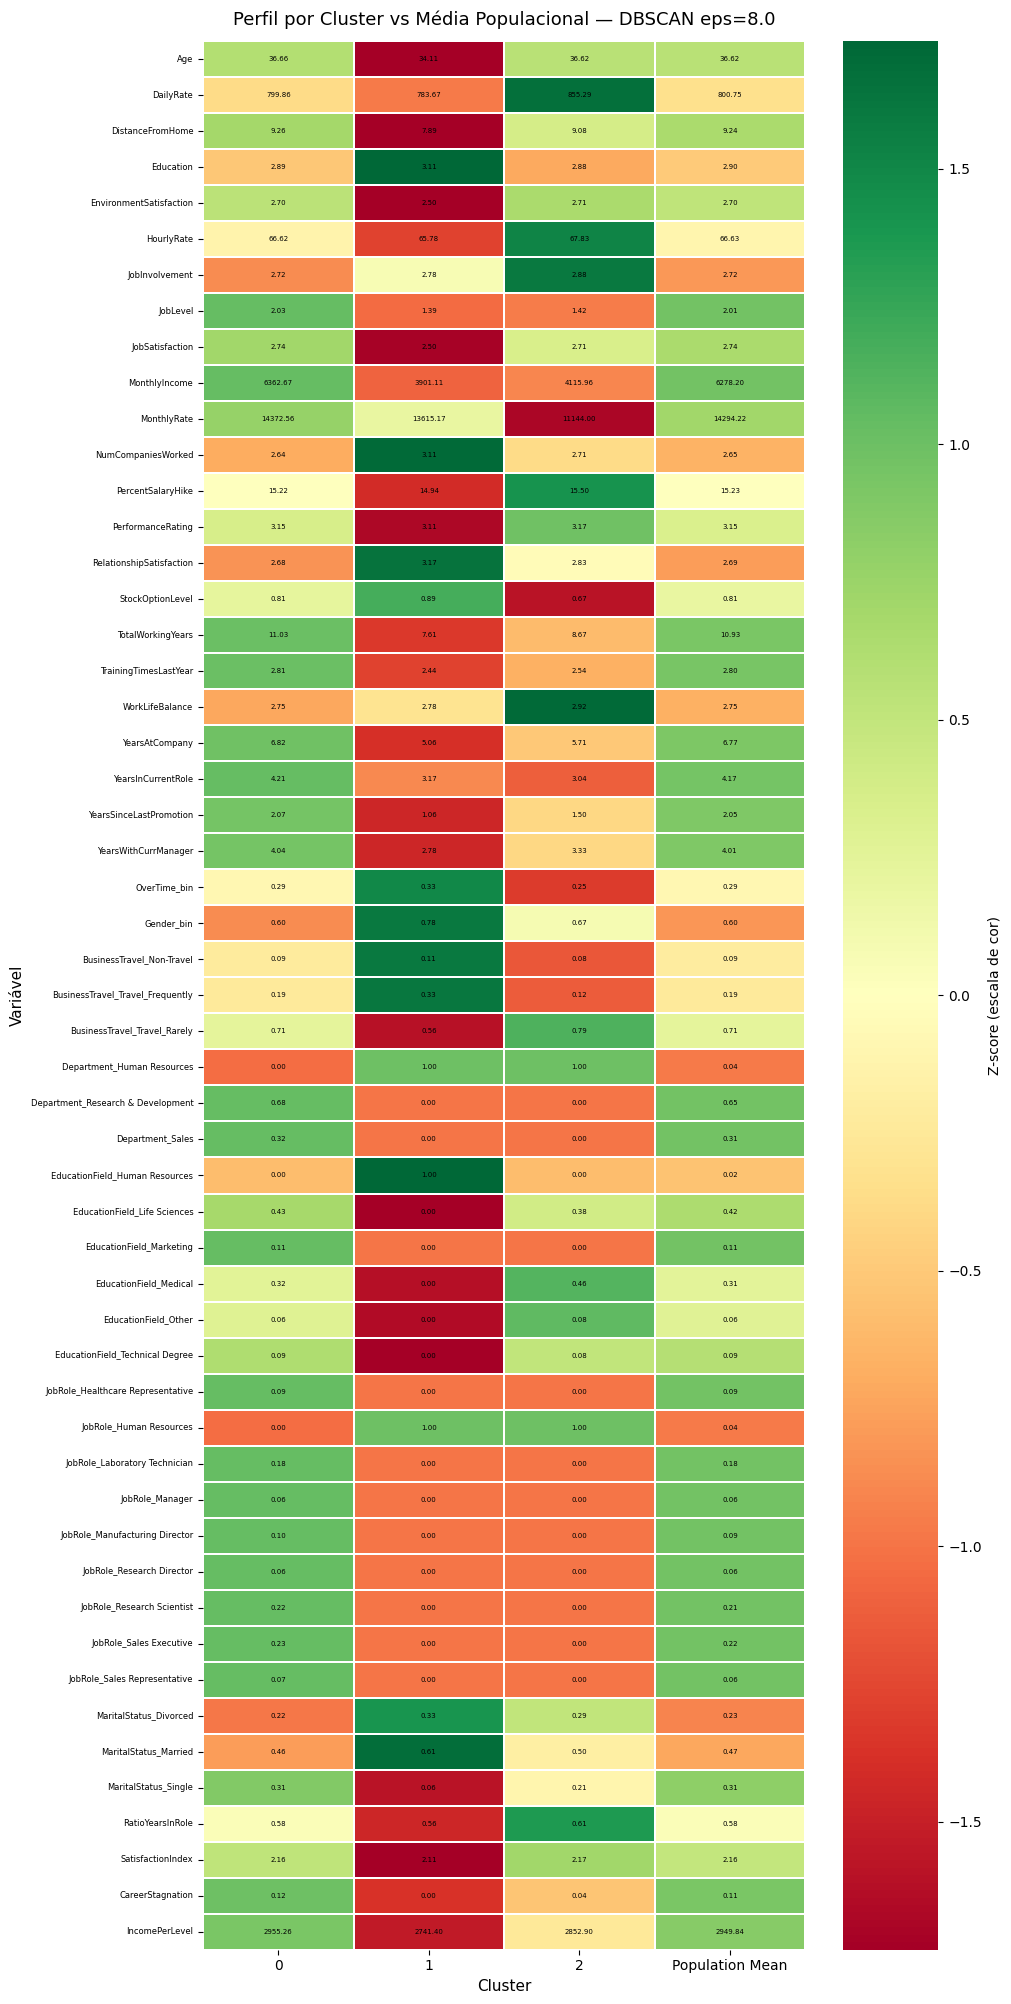

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,RatioYearsInRole,SatisfactionIndex,CareerStagnation,IncomePerLevel
0,36.661909,799.855486,9.264942,2.893845,2.698483,66.622658,2.717217,2.027654,2.743979,6362.665477,...,0.215879,0.225691,0.066905,0.222123,0.464764,0.313113,0.582565,2.162355,0.117752,2955.264377
1,34.111111,783.666667,7.888889,3.111111,2.500000,65.777778,2.777778,1.388889,2.500000,3901.111111,...,0.000000,0.000000,0.000000,0.333333,0.611111,0.055556,0.555616,2.111111,0.000000,2741.398148
2,36.625000,855.291667,9.083333,2.875000,2.708333,67.833333,2.875000,1.416667,2.708333,4115.958333,...,0.000000,0.000000,0.000000,0.291667,0.500000,0.208333,0.606134,2.166667,0.041667,2852.902778
Population Mean,36.621668,800.748925,9.239897,2.896819,2.695615,66.634566,2.721410,2.005159,2.739467,6278.203783,...,0.208083,0.217541,0.064488,0.225279,0.467756,0.306965,0.582634,2.161651,0.114359,2949.841960


In [24]:
mask_hm_db = clusters_train_db != -1
import pandas as _pd
_Xtmp = X_train.iloc[mask_hm_db].copy()
plot_profile_heatmap(_Xtmp, clusters_train_db[mask_hm_db], f'DBSCAN eps={eps_value}')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

## 8. Candidato 3 - GMM

Modelo probabilístico que assume que os dados são gerados a partir de uma mistura de várias distribuições Gaussianas com parâmetros desconhecidos.

### 8.1 Pesquisa do número ótimo de componentes (treino)

In [25]:
melhor_n_gmm = 4
print(f'n_components GMM fixo: {melhor_n_gmm}')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

n_components GMM fixo: 4


In [26]:
# Gráfico de pesquisa GMM removido — n_components fixo em 4
print('n_components=4 definido diretamente, sem pesquisa.')


n_components=4 definido diretamente, sem pesquisa.


### 8.2 Treino do modelo final e métricas treino vs teste

In [27]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

# Escolha do melhor número de componentes com base no Silhouette do treino
gmm_final = GaussianMixture(
    n_components=melhor_n_gmm,
    covariance_type='full')

# Fit no treino
gmm_final.fit(X_train_scaled)

# Labels treino e teste
clusters_train_gmm = gmm_final.predict(X_train_scaled)
clusters_test_gmm = gmm_final.predict(X_test_scaled)

# Métricas treino
sil_train_gmm = silhouette_score(X_train_scaled, clusters_train_gmm)
db_train_gmm = davies_bouldin_score(X_train_scaled, clusters_train_gmm)
ch_train_gmm = calinski_harabasz_score(X_train_scaled, clusters_train_gmm)

# Métricas teste
sil_test_gmm = silhouette_score(X_test_scaled, clusters_test_gmm)
db_test_gmm = davies_bouldin_score(X_test_scaled, clusters_test_gmm)
ch_test_gmm = calinski_harabasz_score(X_test_scaled, clusters_test_gmm)

print(f"===== GMM n={melhor_n_gmm} — TREINO vs TESTE =====")
print(f"{'Métrica':<25} {'Treino':>10} {'Teste':>10} {'Diferença':>12}")
print("-" * 60)
print(f"{'Silhouette Score':<25} {sil_train_gmm:>10.4f} {sil_test_gmm:>10.4f} {abs(sil_train_gmm-sil_test_gmm):>12.4f}")
print(f"{'Davies-Bouldin':<25} {db_train_gmm:>10.4f} {db_test_gmm:>10.4f} {abs(db_train_gmm-db_test_gmm):>12.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_train_gmm:>10.2f} {ch_test_gmm:>10.2f} {abs(ch_train_gmm-ch_test_gmm):>12.2f}")

print(f"\nMeta Silhouette > 0.50 (Treino): {'ATINGIDA' if sil_train_gmm > 0.50 else 'NÃO ATINGIDA'}")
print(f"Meta Silhouette > 0.50 (Teste): {'ATINGIDA' if sil_test_gmm > 0.50 else 'NÃO ATINGIDA'}")

print("\nDistribuição clusters — Treino:")
print(pd.Series(clusters_train_gmm).value_counts().sort_index().to_string())

print("\nDistribuição clusters — Teste:")
print(pd.Series(clusters_test_gmm).value_counts().sort_index().to_string())

===== GMM n=4 — TREINO vs TESTE =====
Métrica                       Treino      Teste    Diferença
------------------------------------------------------------
Silhouette Score              0.0804     0.0787       0.0017
Davies-Bouldin                3.3393     3.2326       0.1067
Calinski-Harabasz              72.80      19.07        53.72

Meta Silhouette > 0.50 (Treino): NÃO ATINGIDA
Meta Silhouette > 0.50 (Teste): NÃO ATINGIDA

Distribuição clusters — Treino:
0    446
1    328
2    253
3    149

Distribuição clusters — Teste:
0    105
1     80
2     74
3     35


### 8.3 Probabilidades de pertença aos clusters

In [28]:
prob_train_gmm = gmm_final.predict_proba(X_train_scaled)
prob_test_gmm = gmm_final.predict_proba(X_test_scaled)

# Confiança média do modelo na atribuição do cluster
conf_train_gmm = prob_train_gmm.max(axis=1)
conf_test_gmm = prob_test_gmm.max(axis=1)

print("===== CONFIANÇA DAS ATRIBUIÇÕES (GMM) =====")
print(f"Confiança média no treino: {conf_train_gmm.mean():.4f}")
print(f"Confiança média no teste:  {conf_test_gmm.mean():.4f}")
print(f"Confiança mínima no treino: {conf_train_gmm.min():.4f}")
print(f"Confiança mínima no teste:  {conf_test_gmm.min():.4f}")

===== CONFIANÇA DAS ATRIBUIÇÕES (GMM) =====
Confiança média no treino: 0.9999
Confiança média no teste:  1.0000
Confiança mínima no treino: 0.8408
Confiança mínima no teste:  1.0000


### 8.4 Distribuição da confiança das atribuições

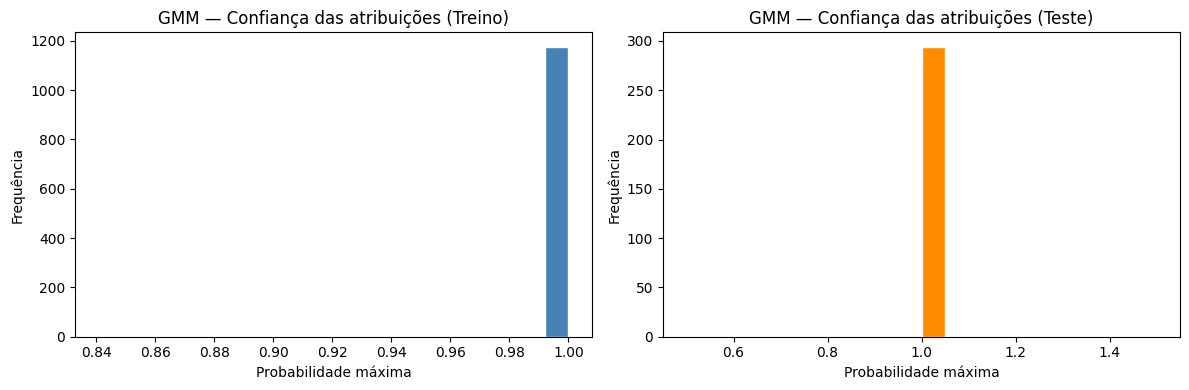

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(conf_train_gmm, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('GMM — Confiança das atribuições (Treino)')
axes[0].set_xlabel('Probabilidade máxima')
axes[0].set_ylabel('Frequência')

axes[1].hist(conf_test_gmm, bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('GMM — Confiança das atribuições (Teste)')
axes[1].set_xlabel('Probabilidade máxima')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('gmm_confianca_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.5 Visualização PCA - GMM Treino vs. Teste

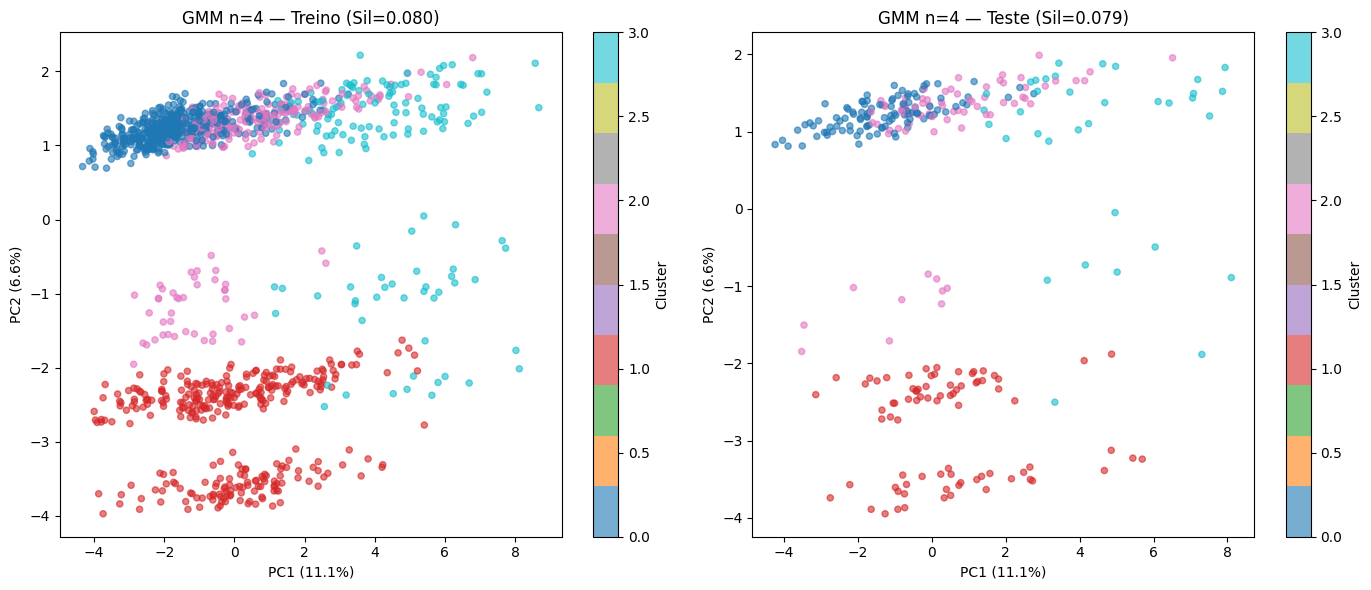

In [30]:
from sklearn.decomposition import PCA

pca_gmm = PCA(n_components=2)
X_train_pca_gmm = pca_gmm.fit_transform(X_train_scaled)
X_test_pca_gmm = pca_gmm.transform(X_test_scaled)
var_gmm = pca_gmm.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(
    X_train_pca_gmm[:, 0], X_train_pca_gmm[:, 1],
    c=clusters_train_gmm, cmap='tab10', alpha=0.6, s=20
)
axes[0].set_title(f'GMM n={melhor_n_gmm} — Treino (Sil={sil_train_gmm:.3f})')
axes[0].set_xlabel(f'PC1 ({var_gmm[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_gmm[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(
    X_test_pca_gmm[:, 0], X_test_pca_gmm[:, 1],
    c=clusters_test_gmm, cmap='tab10', alpha=0.6, s=20
)
axes[1].set_title(f'GMM n={melhor_n_gmm} — Teste (Sil={sil_test_gmm:.3f})')
axes[1].set_xlabel(f'PC1 ({var_gmm[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_gmm[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('gmm_pca_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.6 Distribuição dos Clusters - GMM Treino vs. Teste

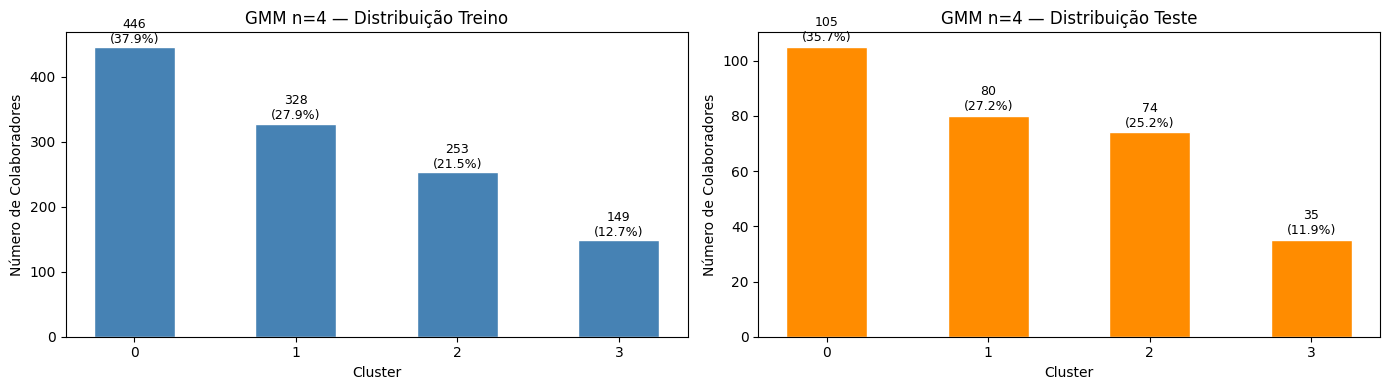

In [31]:
contagem_gmm_train = pd.Series(clusters_train_gmm).value_counts().sort_index()
contagem_gmm_test = pd.Series(clusters_test_gmm).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars1 = axes[0].bar(contagem_gmm_train.index, contagem_gmm_train.values,
                    color='steelblue', edgecolor='white', width=0.5)

for bar, val in zip(bars1, contagem_gmm_train.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{val}\n({val/len(clusters_train_gmm)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title(f'GMM n={melhor_n_gmm} — Distribuição Treino')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Número de Colaboradores')
axes[0].set_xticks(contagem_gmm_train.index)

bars2 = axes[1].bar(contagem_gmm_test.index, contagem_gmm_test.values,
                    color='darkorange', edgecolor='white', width=0.5)

for bar, val in zip(bars2, contagem_gmm_test.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val}\n({val/len(clusters_test_gmm)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )

axes[1].set_title(f'GMM n={melhor_n_gmm} — Distribuição Teste')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Número de Colaboradores')
axes[1].set_xticks(contagem_gmm_test.index)

plt.tight_layout()
plt.savefig('gmm_distribuicao_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.7 Silhouette Plot - GMM (Treino)

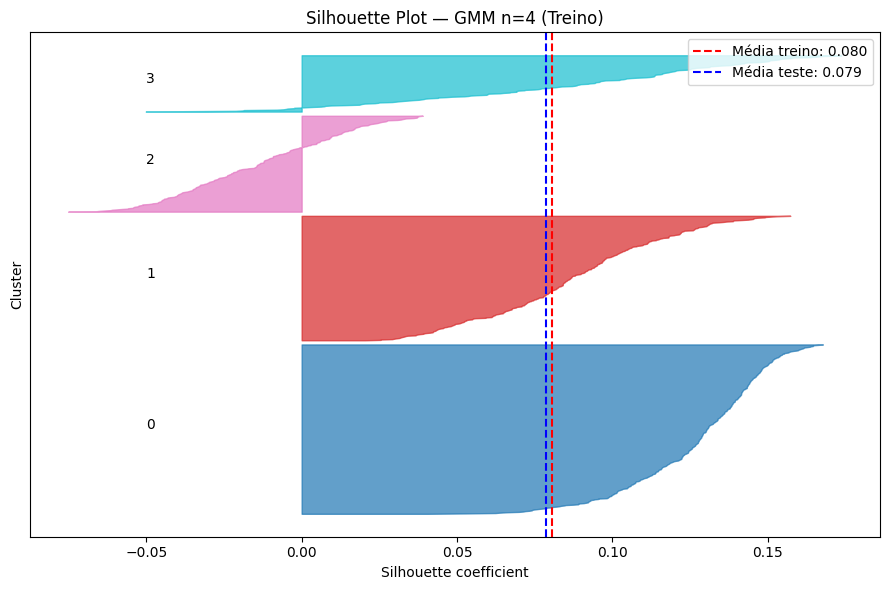

In [32]:
from sklearn.metrics import silhouette_samples
import numpy as np

sample_sil_gmm = silhouette_samples(X_train_scaled, clusters_train_gmm)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, melhor_n_gmm))

for i in range(melhor_n_gmm):
    vals = sample_sil_gmm[clusters_train_gmm == i]
    vals.sort()
    size = vals.shape[0]
    y_upper = y_lower + size
    
    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, vals,
        facecolor=colors[i], edgecolor=colors[i], alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_gmm, color='red', linestyle='--', linewidth=1.5,
           label=f'Média treino: {sil_train_gmm:.3f}')
ax.axvline(sil_test_gmm, color='blue', linestyle='--', linewidth=1.5,
           label=f'Média teste: {sil_test_gmm:.3f}')

ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — GMM n={melhor_n_gmm} (Treino)')
ax.set_yticks([])
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('silhouette_gmm_treino.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.8 Caracterização dos Clusters

In [33]:
df_gmm_perf = X_train.copy()
df_gmm_perf['Cluster'] = clusters_train_gmm

cols_perfil_gmm = [
    col for col in ['Age', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears',
                    'YearsAtCompany', 'SatisfactionIndex', 'WorkLifeBalance',
                    'OverTime_bin', 'IncomePerLevel', 'RatioYearsInRole']
    if col in df_gmm_perf.columns
]

perfil_gmm = df_gmm_perf.groupby('Cluster')[cols_perfil_gmm].mean().round(3)

print("===== PERFIL MÉDIO POR CLUSTER — GMM =====")
display(perfil_gmm)

===== PERFIL MÉDIO POR CLUSTER — GMM =====


,Age,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,SatisfactionIndex,WorkLifeBalance,OverTime_bin,IncomePerLevel,RatioYearsInRole
Cluster,,,,,,,,,,
0,34.036,3137.767,1.191,7.500,4.982,2.132,2.666,0.298,2709.643,0.552
1,35.332,5914.787,2.037,9.534,6.348,2.146,2.829,0.296,2831.760,0.608
2,38.320,6771.609,2.269,12.458,7.538,2.213,2.759,0.269,2935.114,0.617
3,45.523,16464.007,4.107,23.168,13.007,2.181,2.826,0.275,4032.355,0.544


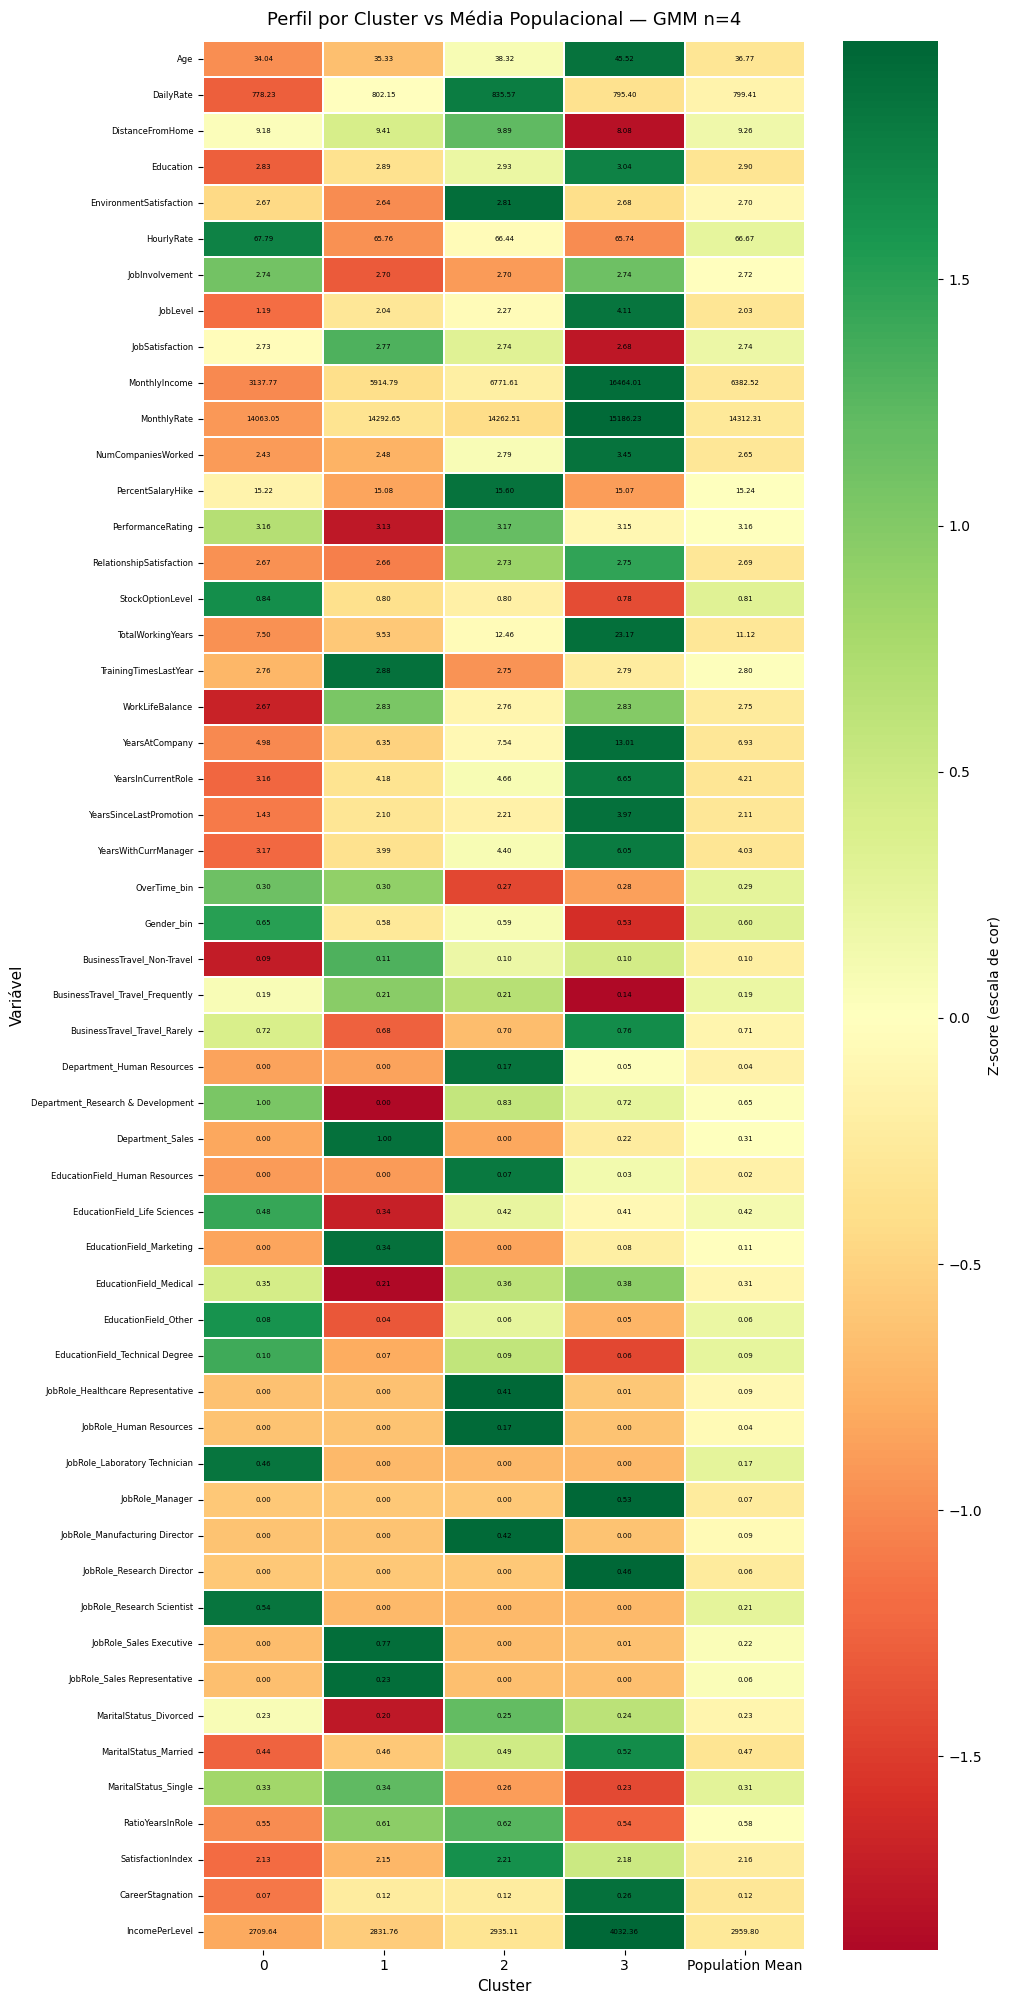

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,RatioYearsInRole,SatisfactionIndex,CareerStagnation,IncomePerLevel
0,34.035874,778.228700,9.183857,2.829596,2.674888,67.789238,2.744395,1.190583,2.728700,3137.766816,...,0.542601,0.000000,0.000000,0.230942,0.441704,0.327354,0.551630,2.132287,0.067265,2709.643124
1,35.332317,802.149390,9.414634,2.893293,2.643293,65.756098,2.695122,2.036585,2.768293,5914.786585,...,0.000000,0.771341,0.228659,0.195122,0.460366,0.344512,0.608015,2.146341,0.121951,2831.759654
2,38.320158,835.565217,9.889328,2.932806,2.810277,66.438735,2.703557,2.268775,2.739130,6771.608696,...,0.000000,0.000000,0.000000,0.252964,0.490119,0.256917,0.617279,2.213439,0.122530,2935.114295
3,45.523490,795.395973,8.080537,3.040268,2.677852,65.738255,2.744966,4.107383,2.677852,16464.006711,...,0.000000,0.006711,0.000000,0.241611,0.523490,0.234899,0.544390,2.181208,0.255034,4032.355257
Population Mean,36.774660,799.410714,9.260204,2.896259,2.695578,66.671769,2.721939,2.028061,2.735544,6382.523810,...,0.205782,0.215986,0.063776,0.227041,0.467687,0.305272,0.580563,2.159864,0.118197,2959.798342


In [34]:
plot_profile_heatmap(X_train, clusters_train_gmm, f'GMM n={melhor_n_gmm}')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

## 9. Candidato 4 - Agglomerative Clustering

Algoritmo que utiliza uma estratégia bottom-up: cada observação começa no seu próprio cluster e os pares de clusters são mesclados sucessivamente à medida que se sobe na hierarquia.

### 9.1 Treino do modelo (Treino)

In [35]:
from sklearn.cluster import AgglomerativeClustering

n_clusters_hc = melhor_k

hc = AgglomerativeClustering(
    n_clusters=n_clusters_hc,
    linkage='ward'
)

clusters_train_hc = hc.fit_predict(X_train_scaled)

### 9.2 Aplicação ao Teste

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn_hc = KNeighborsClassifier(n_neighbors=5)
knn_hc.fit(X_train_scaled, clusters_train_hc)

clusters_test_hc = knn_hc.predict(X_test_scaled)

### 9.3 Métricas

In [37]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# TREINO
sil_train_hc = silhouette_score(X_train_scaled, clusters_train_hc)
db_train_hc = davies_bouldin_score(X_train_scaled, clusters_train_hc)
ch_train_hc = calinski_harabasz_score(X_train_scaled, clusters_train_hc)

# TESTE
sil_test_hc = silhouette_score(X_test_scaled, clusters_test_hc)
db_test_hc = davies_bouldin_score(X_test_scaled, clusters_test_hc)
ch_test_hc = calinski_harabasz_score(X_test_scaled, clusters_test_hc)

print("===== HIERÁRQUICO — TREINO vs TESTE =====")
print(f"{'Métrica':<25} {'Treino':>10} {'Teste':>10} {'Diferença':>12}")
print("-"*60)
print(f"{'Silhouette Score':<25} {sil_train_hc:>10.4f} {sil_test_hc:>10.4f} {abs(sil_train_hc-sil_test_hc):>12.4f}")
print(f"{'Davies-Bouldin':<25} {db_train_hc:>10.4f} {db_test_hc:>10.4f} {abs(db_train_hc-db_test_hc):>12.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_train_hc:>10.2f} {ch_test_hc:>10.2f} {abs(ch_train_hc-ch_test_hc):>12.2f}")

print(f"\nMeta Silhouette > 0.50 (Treino): {'ATINGIDA' if sil_train_hc > 0.50 else 'NÃO ATINGIDA'}")
print(f"Meta Silhouette > 0.50 (Teste): {'ATINGIDA' if sil_test_hc > 0.50 else 'NÃO ATINGIDA'}")

===== HIERÁRQUICO — TREINO vs TESTE =====
Métrica                       Treino      Teste    Diferença
------------------------------------------------------------
Silhouette Score              0.0785     0.0809       0.0025
Davies-Bouldin                2.7545     2.6197       0.1348
Calinski-Harabasz              72.43      18.64        53.79

Meta Silhouette > 0.50 (Treino): NÃO ATINGIDA
Meta Silhouette > 0.50 (Teste): NÃO ATINGIDA


### 9.4 PCA

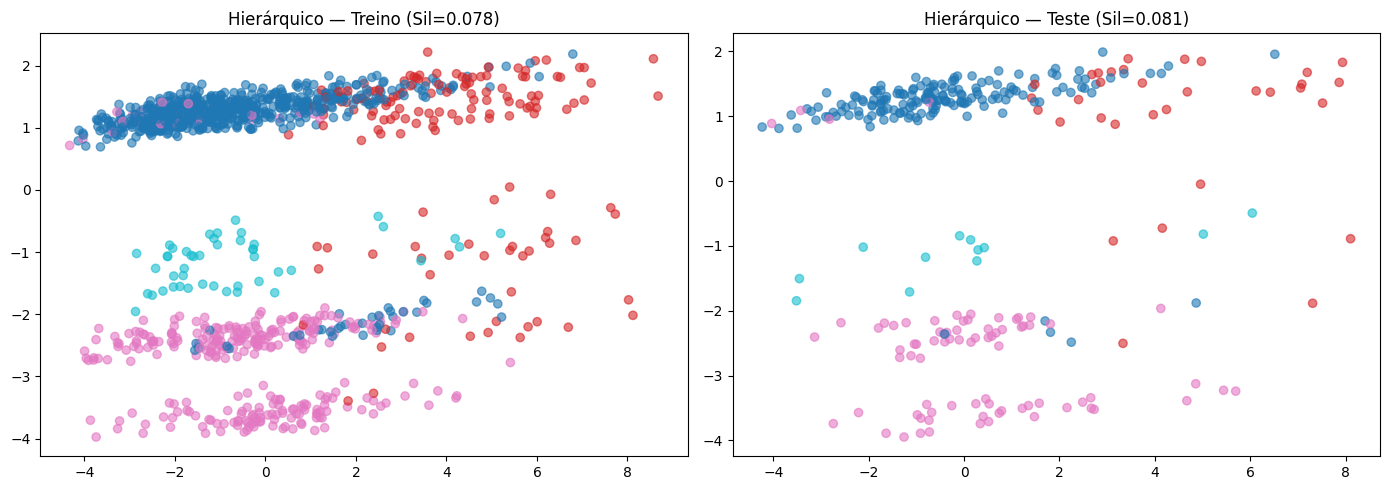

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca_hc = pca.fit_transform(X_train_scaled)
X_test_pca_hc = pca.transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train_pca_hc[:, 0], X_train_pca_hc[:, 1],
                c=clusters_train_hc, cmap='tab10', alpha=0.6)
axes[0].set_title(f'Hierárquico — Treino (Sil={sil_train_hc:.3f})')

axes[1].scatter(X_test_pca_hc[:, 0], X_test_pca_hc[:, 1],
                c=clusters_test_hc, cmap='tab10', alpha=0.6)
axes[1].set_title(f'Hierárquico — Teste (Sil={sil_test_hc:.3f})')

plt.tight_layout()
plt.show()

### 9.5 Dendrograma

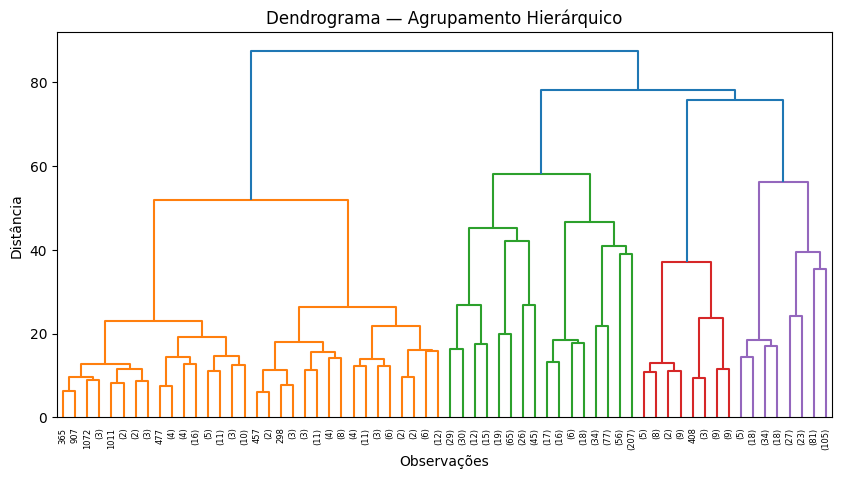

In [39]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_train_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrograma — Agrupamento Hierárquico")
plt.xlabel("Observações")
plt.ylabel("Distância")
plt.show()

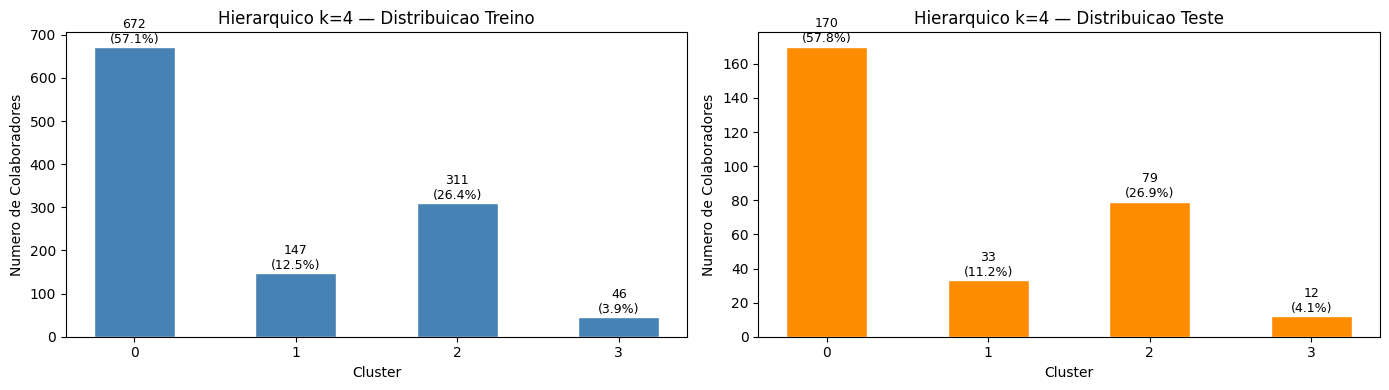

In [40]:
contagem_hc_train = pd.Series(clusters_train_hc).value_counts().sort_index()
contagem_hc_test  = pd.Series(clusters_test_hc).value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bars1 = axes[0].bar(contagem_hc_train.index, contagem_hc_train.values, color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars1, contagem_hc_train.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                f'{val}\n({val/len(clusters_train_hc)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_title(f'Hierarquico k={n_clusters_hc} — Distribuicao Treino')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Numero de Colaboradores')
axes[0].set_xticks(contagem_hc_train.index)
bars2 = axes[1].bar(contagem_hc_test.index, contagem_hc_test.values, color='darkorange', edgecolor='white', width=0.5)
for bar, val in zip(bars2, contagem_hc_test.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{val}\n({val/len(clusters_test_hc)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
axes[1].set_title(f'Hierarquico k={n_clusters_hc} — Distribuicao Teste')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Numero de Colaboradores')
axes[1].set_xticks(contagem_hc_test.index)
plt.tight_layout()
plt.savefig('distribuicao_hierarquico_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

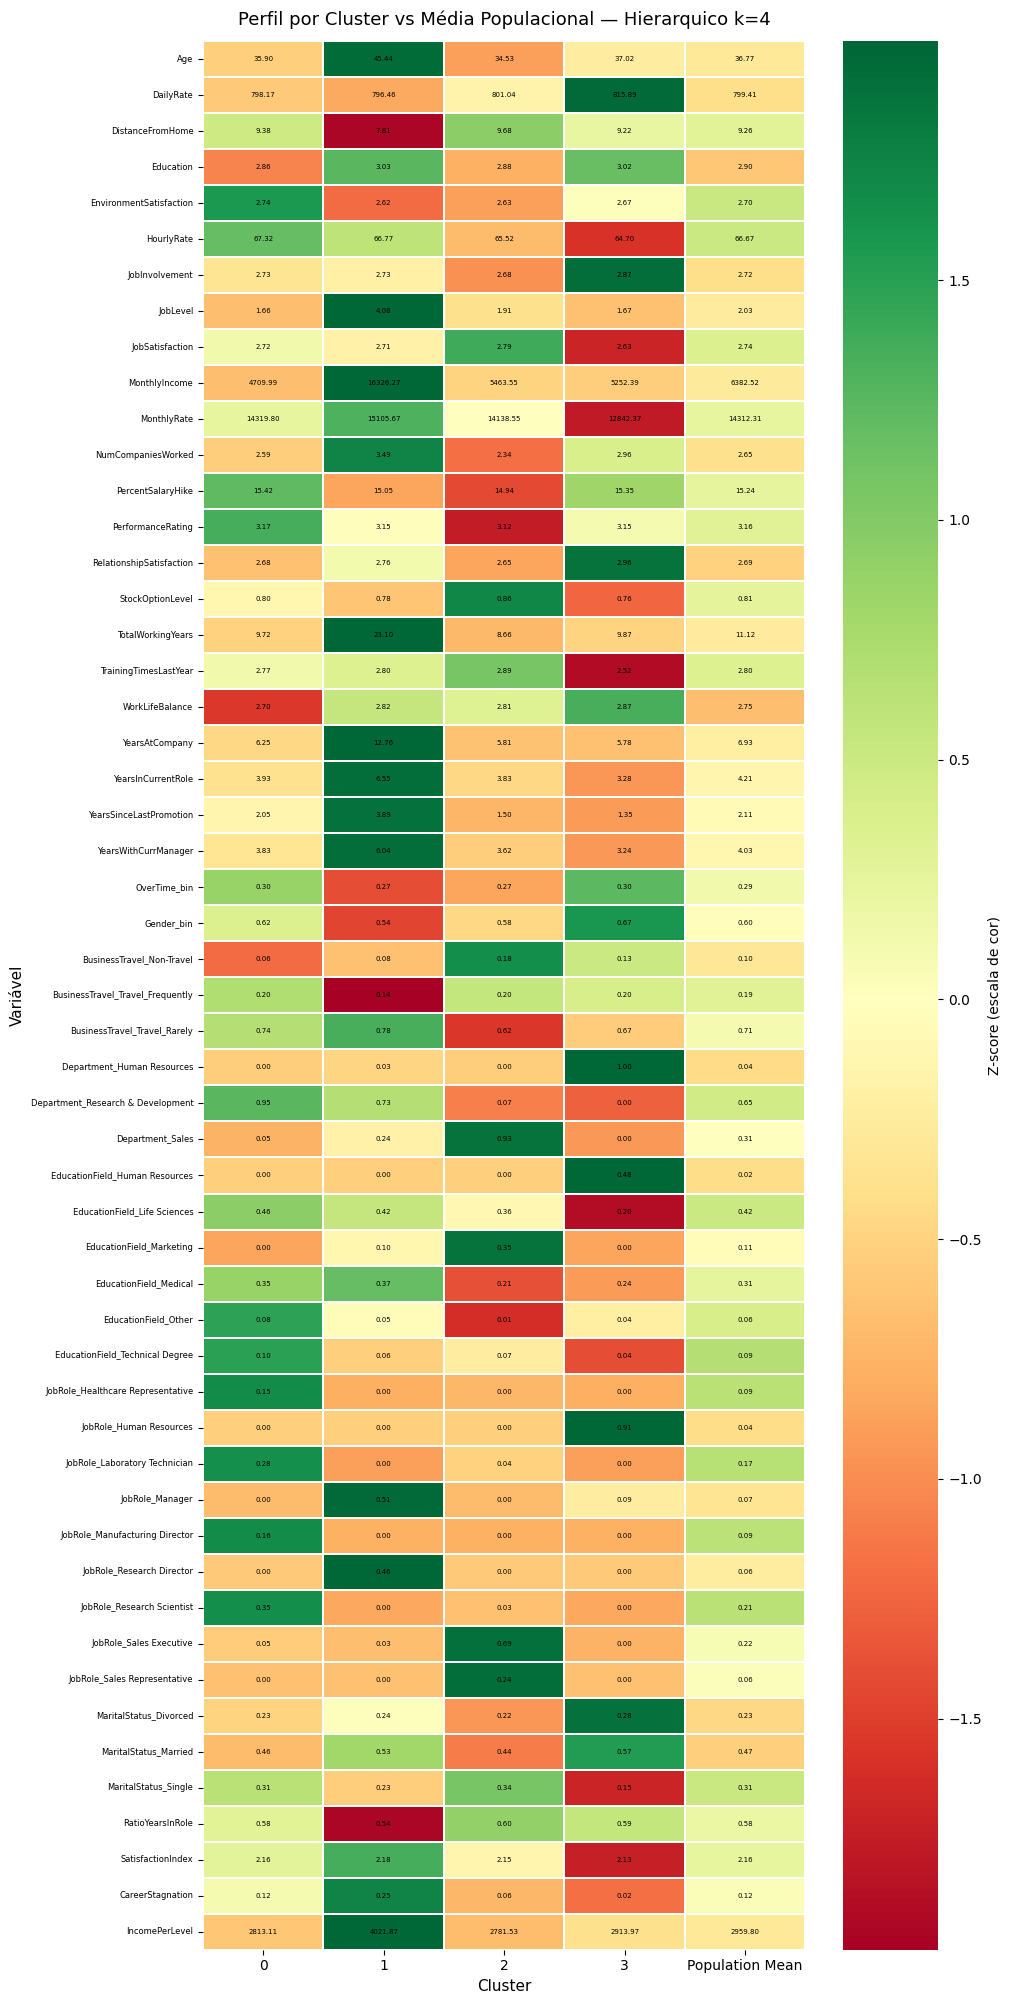

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,RatioYearsInRole,SatisfactionIndex,CareerStagnation,IncomePerLevel
0,35.901786,798.174107,9.383929,2.864583,2.742560,67.316964,2.726190,1.656250,2.724702,4709.986607,...,0.348214,0.053571,0.000000,0.226190,0.459821,0.313988,0.582949,2.160714,0.123512,2813.107639
1,45.435374,796.455782,7.809524,3.027211,2.619048,66.768707,2.734694,4.081633,2.707483,16326.272109,...,0.000000,0.027211,0.000000,0.238095,0.530612,0.231293,0.535542,2.176871,0.251701,4021.874830
2,34.530547,801.041801,9.684887,2.884244,2.633441,65.524116,2.684887,1.913183,2.787781,5463.553055,...,0.025723,0.688103,0.241158,0.215434,0.440514,0.344051,0.595531,2.154341,0.057878,2781.531618
3,37.021739,815.891304,9.217391,3.021739,2.673913,64.695652,2.869565,1.673913,2.630435,5252.391304,...,0.000000,0.000000,0.000000,0.282609,0.565217,0.152174,0.588369,2.130435,0.021739,2913.969203
Population Mean,36.774660,799.410714,9.260204,2.896259,2.695578,66.671769,2.721939,2.028061,2.735544,6382.523810,...,0.205782,0.215986,0.063776,0.227041,0.467687,0.305272,0.580563,2.159864,0.118197,2959.798342


In [41]:
plot_profile_heatmap(X_train, clusters_train_hc, f'Hierarquico k={n_clusters_hc}')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

## 10. Candidato 5 - OPTICS

Extensão do DBSCAN que aborda uma das suas principais fraquezas: a dificuldade em detectar clusters de densidades variadas.

### 10.1 Treino do modelo (Treino)

In [42]:
from sklearn.cluster import OPTICS

optics = OPTICS(
    min_samples=3,
    xi=0.05,          
    min_cluster_size=0.05
)

clusters_train_opt = optics.fit_predict(X_train_scaled)

### 10.2 Diagnóstico inicial

In [43]:
import numpy as np

n_clusters_opt = len(set(clusters_train_opt)) - (1 if -1 in clusters_train_opt else 0)
noise_opt = np.sum(clusters_train_opt == -1)
noise_pct_opt = noise_opt / len(clusters_train_opt) * 100

print("OPTICS TREINO:")
print(f"Clusters encontrados: {n_clusters_opt}")
print(f"Ruído: {noise_opt} ({noise_pct_opt:.1f}%)")
print("\nDistribuição:")
print(pd.Series(clusters_train_opt).value_counts().sort_index())

OPTICS TREINO:
Clusters encontrados: 1
Ruído: 4 (0.3%)

Distribuição:
-1       4
 0    1172
Name: count, dtype: int64


### 10.3 Aplicação ao Teste

In [44]:
from sklearn.neighbors import KNeighborsClassifier

mask_train_opt = clusters_train_opt != -1

knn_opt = KNeighborsClassifier(n_neighbors=5)
knn_opt.fit(X_train_scaled[mask_train_opt], clusters_train_opt[mask_train_opt])

clusters_test_opt = knn_opt.predict(X_test_scaled)

### 10.4 Métricas

In [45]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# remover ruído
mask = clusters_train_opt != -1

if len(set(clusters_train_opt[mask])) > 1:
    sil_train_opt = silhouette_score(X_train_scaled[mask], clusters_train_opt[mask])
    db_train_opt = davies_bouldin_score(X_train_scaled[mask], clusters_train_opt[mask])
    ch_train_opt = calinski_harabasz_score(X_train_scaled[mask], clusters_train_opt[mask])
else:
    sil_train_opt = db_train_opt = ch_train_opt = np.nan

# TESTE
if len(set(clusters_test_opt)) > 1:
    sil_test_opt = silhouette_score(X_test_scaled, clusters_test_opt)
    db_test_opt = davies_bouldin_score(X_test_scaled, clusters_test_opt)
    ch_test_opt = calinski_harabasz_score(X_test_scaled, clusters_test_opt)
else:
    sil_test_opt = db_test_opt = ch_test_opt = np.nan

print("===== OPTICS — TREINO vs TESTE =====")
print(f"{'Métrica':<25} {'Treino':>10} {'Teste':>10} {'Diferença':>12}")
print("-"*60)
print(f"{'Silhouette Score':<25} {sil_train_opt:>10.4f} {sil_test_opt:>10.4f} {abs(sil_train_opt-sil_test_opt):>12.4f}")
print(f"{'Davies-Bouldin':<25} {db_train_opt:>10.4f} {db_test_opt:>10.4f} {abs(db_train_opt-db_test_opt):>12.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_train_opt:>10.2f} {ch_test_opt:>10.2f} {abs(ch_train_opt-ch_test_opt):>12.2f}")

print(f"\nMeta Silhouette > 0.50 (Treino): {'ATINGIDA' if sil_train_opt > 0.50 else 'NÃO ATINGIDA'}")
print(f"Meta Silhouette > 0.50 (Teste): {'ATINGIDA' if sil_test_opt > 0.50 else 'NÃO ATINGIDA'}")

===== OPTICS — TREINO vs TESTE =====
Métrica                       Treino      Teste    Diferença
------------------------------------------------------------
Silhouette Score                 nan        nan          nan
Davies-Bouldin                   nan        nan          nan
Calinski-Harabasz                nan        nan          nan

Meta Silhouette > 0.50 (Treino): NÃO ATINGIDA
Meta Silhouette > 0.50 (Teste): NÃO ATINGIDA


### 10.5 PCA

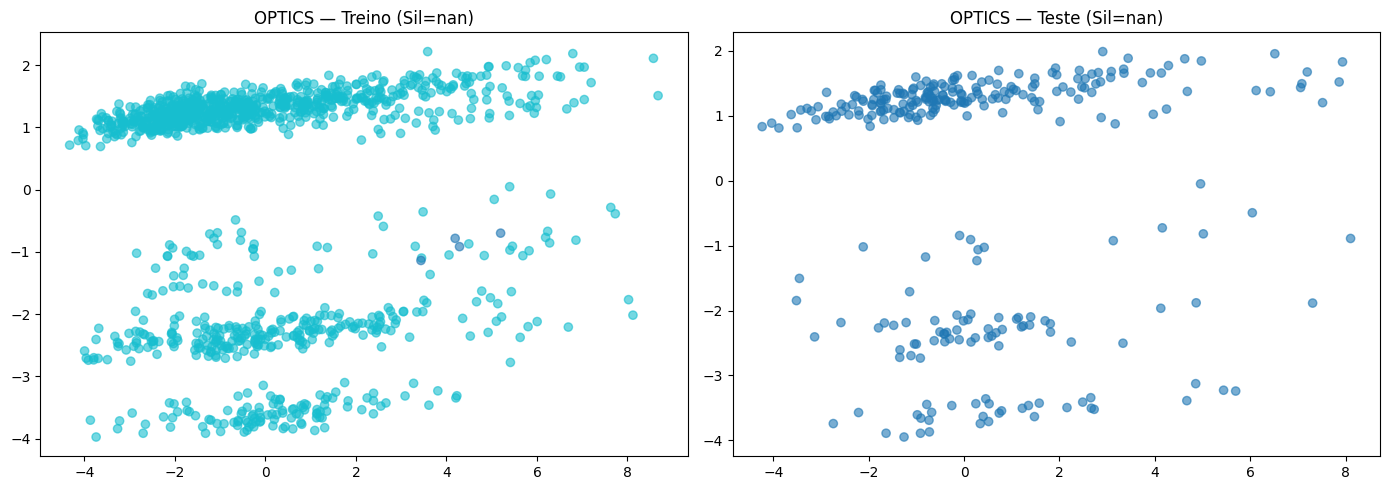

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca_opt = pca.fit_transform(X_train_scaled)
X_test_pca_opt = pca.transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train_pca_opt[:, 0], X_train_pca_opt[:, 1],
                c=clusters_train_opt, cmap='tab10', alpha=0.6)
axes[0].set_title(f'OPTICS — Treino (Sil={sil_train_opt:.3f})')

axes[1].scatter(X_test_pca_opt[:, 0], X_test_pca_opt[:, 1],
                c=clusters_test_opt, cmap='tab10', alpha=0.6)
axes[1].set_title(f'OPTICS — Teste (Sil={sil_test_opt:.3f})')

plt.tight_layout()
plt.show()

### 10.6 Distribuição dos clusters

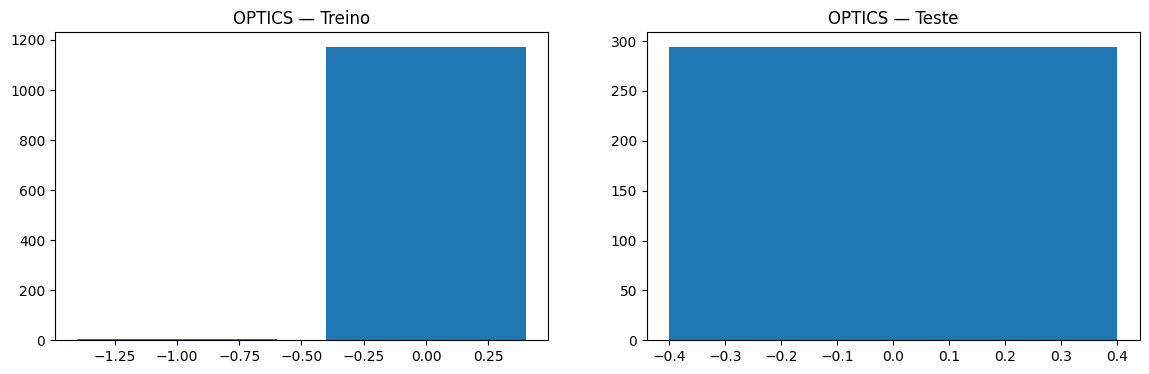

In [47]:
contagem_train = pd.Series(clusters_train_opt).value_counts().sort_index()
contagem_test = pd.Series(clusters_test_opt).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(contagem_train.index, contagem_train.values)
axes[0].set_title("OPTICS — Treino")

axes[1].bar(contagem_test.index, contagem_test.values)
axes[1].set_title("OPTICS — Teste")

plt.show()

O algoritmo OPTICS não identificou múltiplos clusters, atribuindo todas as observações a um único grupo.

## 11. Candidato 6 - MiniBatch K-Means

Uma variante otimizada do K-Means clássico que utiliza pequenos lotes (batches) de dados selecionados aleatoriamente para atualizar os centroides em cada iteração.

### 11.1 Treino do modelo

In [48]:
from sklearn.cluster import MiniBatchKMeans

mbkm = MiniBatchKMeans(
    n_clusters=melhor_k
)

clusters_train_mb = mbkm.fit_predict(X_train_scaled)
clusters_test_mb = mbkm.predict(X_test_scaled)

### 11.2 Métricas treino vs teste

In [49]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

# TREINO
sil_train_mb = silhouette_score(X_train_scaled, clusters_train_mb)
db_train_mb = davies_bouldin_score(X_train_scaled, clusters_train_mb)
ch_train_mb = calinski_harabasz_score(X_train_scaled, clusters_train_mb)

# TESTE
sil_test_mb = silhouette_score(X_test_scaled, clusters_test_mb)
db_test_mb = davies_bouldin_score(X_test_scaled, clusters_test_mb)
ch_test_mb = calinski_harabasz_score(X_test_scaled, clusters_test_mb)

print("===== MINIBATCH K-MEANS — TREINO vs TESTE =====")
print(f"{'Métrica':<25} {'Treino':>10} {'Teste':>10} {'Diferença':>12}")
print("-"*60)
print(f"{'Silhouette Score':<25} {sil_train_mb:>10.4f} {sil_test_mb:>10.4f} {abs(sil_train_mb-sil_test_mb):>12.4f}")
print(f"{'Davies-Bouldin':<25} {db_train_mb:>10.4f} {db_test_mb:>10.4f} {abs(db_train_mb-db_test_mb):>12.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_train_mb:>10.2f} {ch_test_mb:>10.2f} {abs(ch_train_mb-ch_test_mb):>12.2f}")

print(f"\nMeta Silhouette > 0.50 (Treino): {'ATINGIDA' if sil_train_mb > 0.50 else 'NÃO ATINGIDA'}")
print(f"Meta Silhouette > 0.50 (Teste): {'ATINGIDA' if sil_test_mb > 0.50 else 'NÃO ATINGIDA'}")

print("\nDistribuição clusters — Treino:")
print(pd.Series(clusters_train_mb).value_counts().sort_index().to_string())

print("\nDistribuição clusters — Teste:")
print(pd.Series(clusters_test_mb).value_counts().sort_index().to_string())

===== MINIBATCH K-MEANS — TREINO vs TESTE =====
Métrica                       Treino      Teste    Diferença
------------------------------------------------------------
Silhouette Score              0.0645     0.0573       0.0073
Davies-Bouldin                3.2751     3.3177       0.0426
Calinski-Harabasz              72.56      18.55        54.01

Meta Silhouette > 0.50 (Treino): NÃO ATINGIDA
Meta Silhouette > 0.50 (Teste): NÃO ATINGIDA

Distribuição clusters — Treino:
0    244
1    413
2    354
3    165

Distribuição clusters — Teste:
0    69
1    99
2    84
3    42


### 11.3 Visualização PCA - treino vs teste

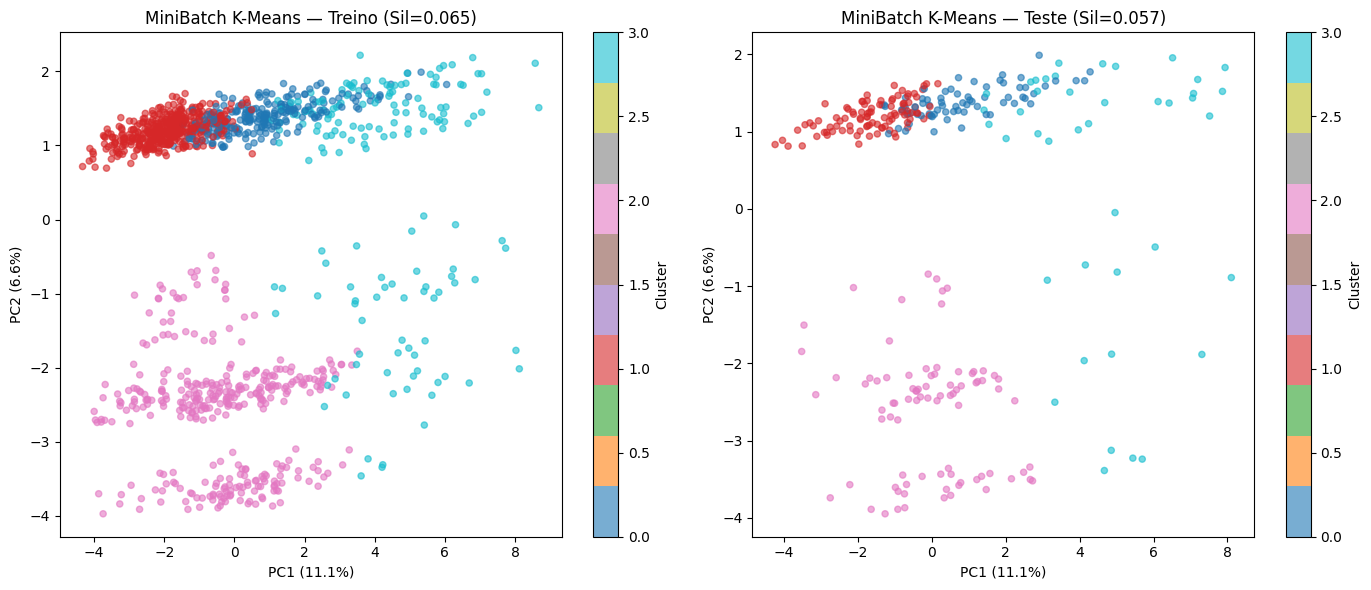

In [50]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_mb = PCA(n_components=2)
X_train_pca_mb = pca_mb.fit_transform(X_train_scaled)
X_test_pca_mb = pca_mb.transform(X_test_scaled)
var_mb = pca_mb.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(
    X_train_pca_mb[:, 0], X_train_pca_mb[:, 1],
    c=clusters_train_mb, cmap='tab10', alpha=0.6, s=20
)
axes[0].set_title(f'MiniBatch K-Means — Treino (Sil={sil_train_mb:.3f})')
axes[0].set_xlabel(f'PC1 ({var_mb[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_mb[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(
    X_test_pca_mb[:, 0], X_test_pca_mb[:, 1],
    c=clusters_test_mb, cmap='tab10', alpha=0.6, s=20
)
axes[1].set_title(f'MiniBatch K-Means — Teste (Sil={sil_test_mb:.3f})')
axes[1].set_xlabel(f'PC1 ({var_mb[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_mb[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('minibatch_kmeans_pca_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.4 Distribuição dos clusters

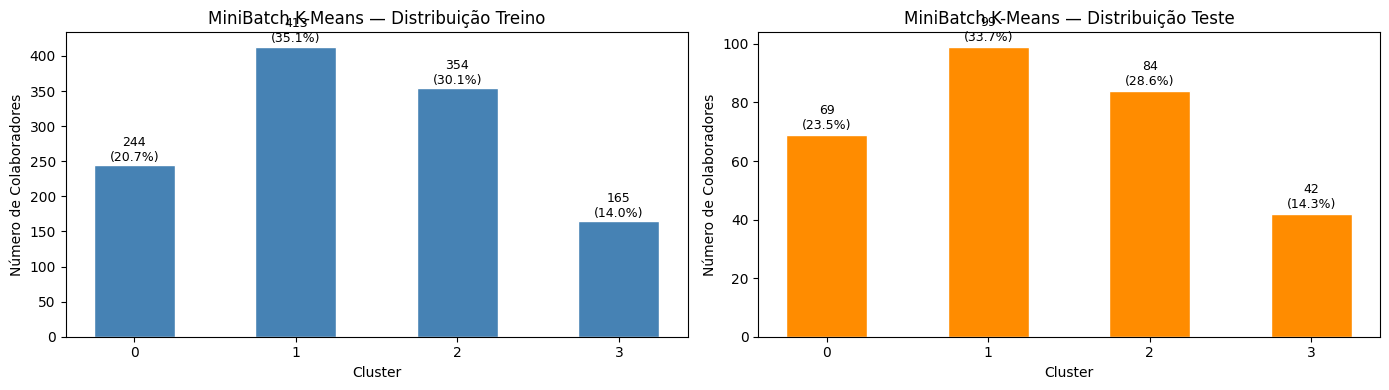

In [51]:
contagem_mb_train = pd.Series(clusters_train_mb).value_counts().sort_index()
contagem_mb_test = pd.Series(clusters_test_mb).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars1 = axes[0].bar(contagem_mb_train.index, contagem_mb_train.values,
                    color='steelblue', edgecolor='white', width=0.5)

for bar, val in zip(bars1, contagem_mb_train.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{val}\n({val/len(clusters_train_mb)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title('MiniBatch K-Means — Distribuição Treino')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Número de Colaboradores')
axes[0].set_xticks(contagem_mb_train.index)

bars2 = axes[1].bar(contagem_mb_test.index, contagem_mb_test.values,
                    color='darkorange', edgecolor='white', width=0.5)

for bar, val in zip(bars2, contagem_mb_test.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val}\n({val/len(clusters_test_mb)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )

axes[1].set_title('MiniBatch K-Means — Distribuição Teste')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Número de Colaboradores')
axes[1].set_xticks(contagem_mb_test.index)

plt.tight_layout()
plt.savefig('minibatch_kmeans_distribuicao_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.5 Silhouette plot - treino

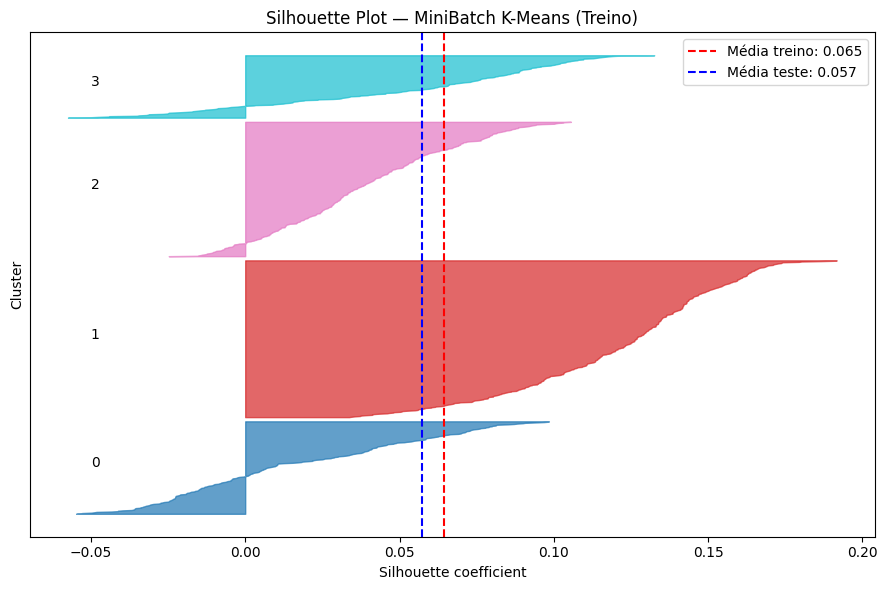

In [52]:
from sklearn.metrics import silhouette_samples

sample_sil_mb = silhouette_samples(X_train_scaled, clusters_train_mb)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, melhor_k))

for i in range(melhor_k):
    vals = sample_sil_mb[clusters_train_mb == i]
    vals.sort()
    size = vals.shape[0]
    y_upper = y_lower + size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, vals,
        facecolor=colors[i], edgecolor=colors[i], alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_mb, color='red', linestyle='--', linewidth=1.5,
           label=f'Média treino: {sil_train_mb:.3f}')
ax.axvline(sil_test_mb, color='blue', linestyle='--', linewidth=1.5,
           label=f'Média teste: {sil_test_mb:.3f}')

ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — MiniBatch K-Means (Treino)')
ax.set_yticks([])
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('silhouette_minibatch_kmeans_treino.png', dpi=150, bbox_inches='tight')
plt.show()

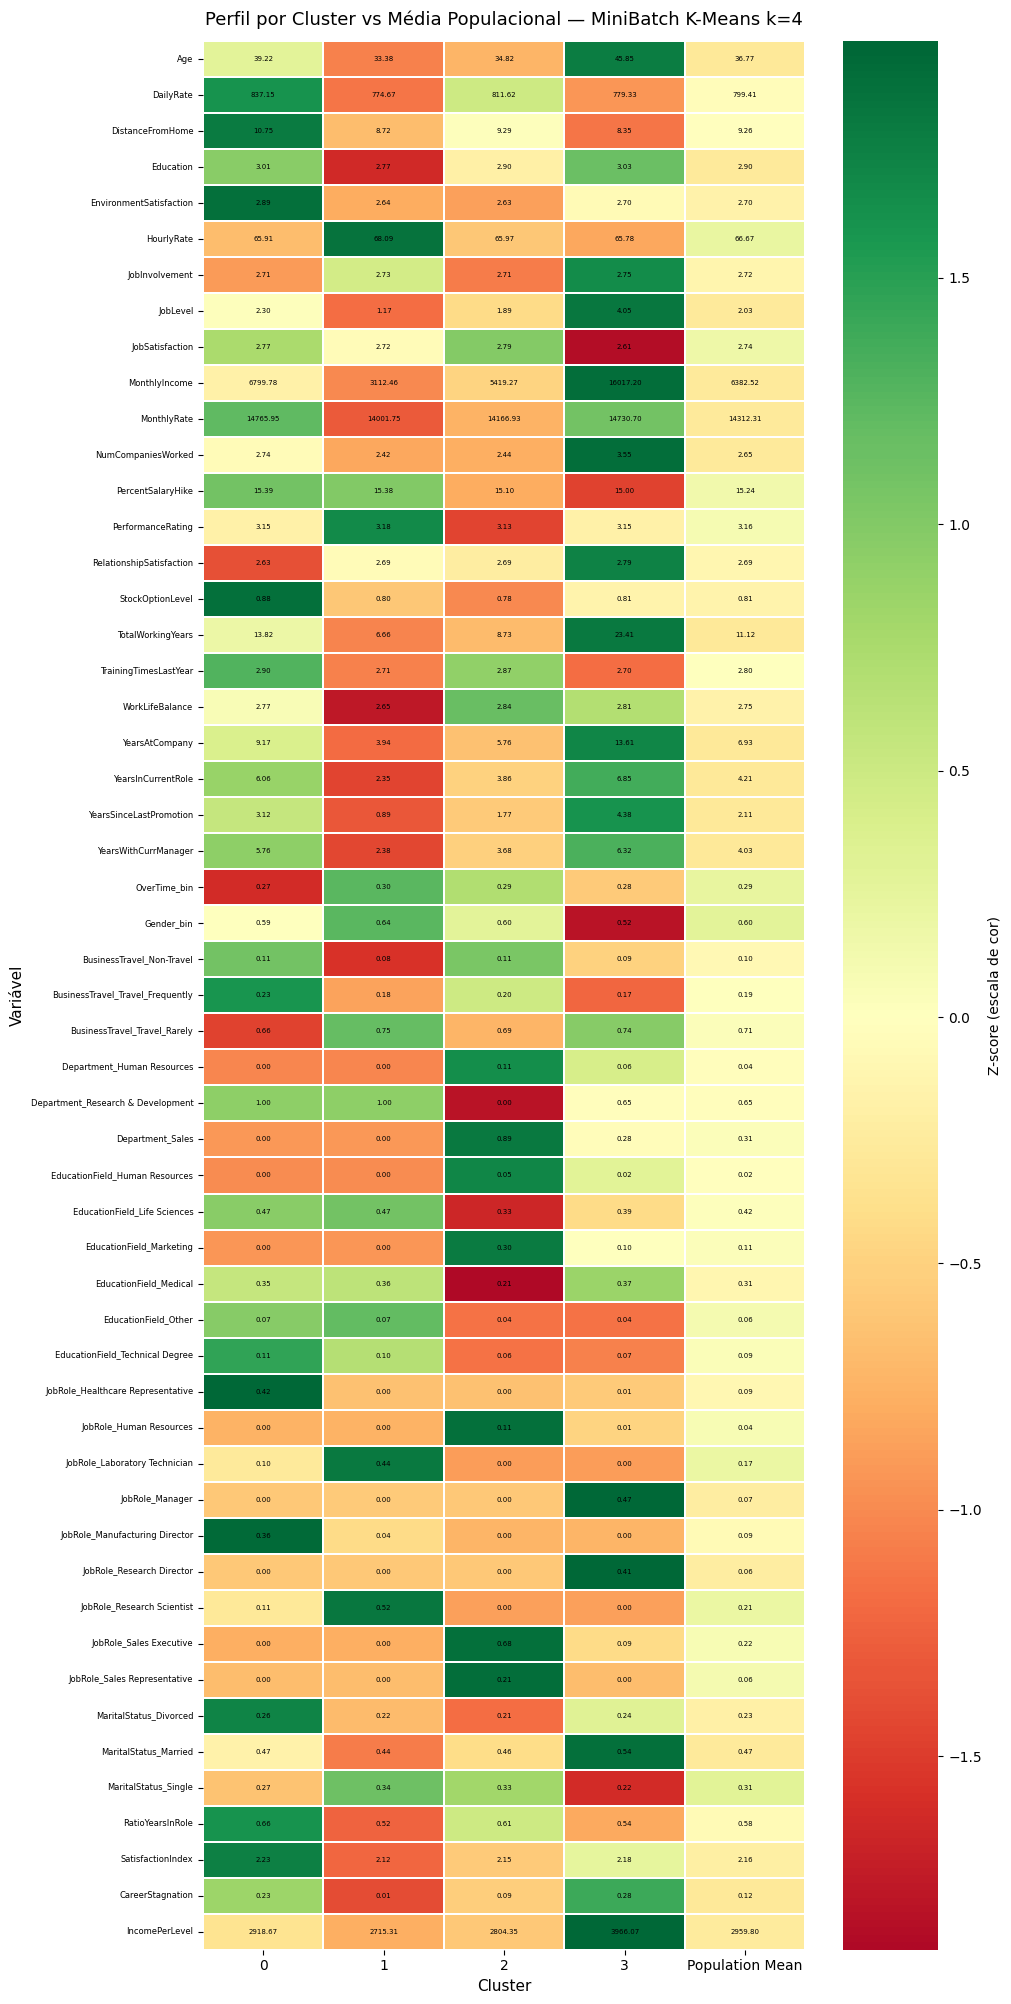

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,RatioYearsInRole,SatisfactionIndex,CareerStagnation,IncomePerLevel
0,39.221311,837.151639,10.750000,3.012295,2.885246,65.905738,2.709016,2.303279,2.770492,6799.778689,...,0.114754,0.000000,0.000000,0.262295,0.471311,0.266393,0.662727,2.229508,0.229508,2918.672473
1,33.380145,774.668281,8.721550,2.767554,2.636804,68.087167,2.731235,1.171913,2.721550,3112.455206,...,0.518160,0.000000,0.000000,0.217918,0.440678,0.341404,0.523232,2.123487,0.007264,2715.313559
2,34.816384,811.624294,9.285311,2.903955,2.629944,65.966102,2.706215,1.892655,2.785311,5419.265537,...,0.000000,0.675141,0.211864,0.209040,0.463277,0.327684,0.607948,2.146893,0.093220,2804.350753
3,45.854545,779.327273,8.351515,3.030303,2.703030,65.775758,2.751515,4.054545,2.612121,16017.200000,...,0.000000,0.090909,0.000000,0.236364,0.539394,0.224242,0.543806,2.175758,0.284848,3966.073333
Population Mean,36.774660,799.410714,9.260204,2.896259,2.695578,66.671769,2.721939,2.028061,2.735544,6382.523810,...,0.205782,0.215986,0.063776,0.227041,0.467687,0.305272,0.580563,2.159864,0.118197,2959.798342


In [53]:
plot_profile_heatmap(X_train, clusters_train_mb, f'MiniBatch K-Means k={melhor_k}')
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

### 11.6 Caracterização dos clusters

In [54]:
df_mb_perf = X_train.copy()
df_mb_perf['Cluster'] = clusters_train_mb

cols_perfil_mb = [
    col for col in ['Age', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears',
                    'YearsAtCompany', 'SatisfactionIndex', 'WorkLifeBalance',
                    'OverTime_bin', 'IncomePerLevel', 'RatioYearsInRole']
    if col in df_mb_perf.columns
]

perfil_mb = df_mb_perf.groupby('Cluster')[cols_perfil_mb].mean().round(3)

print("===== PERFIL MÉDIO POR CLUSTER — MINIBATCH K-MEANS =====")
display(perfil_mb)

===== PERFIL MÉDIO POR CLUSTER — MINIBATCH K-MEANS =====


,Age,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,SatisfactionIndex,WorkLifeBalance,OverTime_bin,IncomePerLevel,RatioYearsInRole
Cluster,,,,,,,,,,
0,39.221,6799.779,2.303,13.820,9.168,2.230,2.766,0.266,2918.672,0.663
1,33.380,3112.455,1.172,6.659,3.944,2.123,2.649,0.300,2715.314,0.523
2,34.816,5419.266,1.893,8.732,5.757,2.147,2.836,0.294,2804.351,0.608
3,45.855,16017.200,4.055,23.412,13.606,2.176,2.806,0.279,3966.073,0.544


## 12 Comparação dos modelos

In [55]:
import pandas as pd
import numpy as np

# ================================
# TABELA FINAL — COMPARAÇÃO MODELOS
# ================================

resultados_finais = pd.DataFrame([
    {
        "Modelo": "K-Means Baseline",
        "Treino_Silhouette": sil_train_base,
        "Teste_Silhouette": sil_test_base,
        "Treino_DB": db_train_base,
        "Teste_DB": db_test_base,
        "Treino_CH": ch_train_base,
        "Teste_CH": ch_test_base,
        "Meta_Silhouette_0.50": "Sim" if sil_test_base > 0.50 else "Não"
    },
    {
        "Modelo": f"K-Means Otimizado (k={melhor_k})",
        "Treino_Silhouette": sil_train_km,
        "Teste_Silhouette": sil_test_km,
        "Treino_DB": db_train_km,
        "Teste_DB": db_test_km,
        "Treino_CH": ch_train_km,
        "Teste_CH": ch_test_km,
        "Meta_Silhouette_0.50": "Sim" if sil_test_km > 0.50 else "Não"
    },
    {
        "Modelo": f"DBSCAN (eps={eps_value})",
        "Treino_Silhouette": sil_train_db,
        "Teste_Silhouette": sil_test_db,
        "Treino_DB": db_train_db,
        "Teste_DB": db_test_db,
        "Treino_CH": ch_train_db,
        "Teste_CH": ch_test_db,
        "Meta_Silhouette_0.50": "Sim" if sil_test_db > 0.50 else "Não"
    },
    {
        "Modelo": f"GMM (n={melhor_n_gmm})",
        "Treino_Silhouette": sil_train_gmm,
        "Teste_Silhouette": sil_test_gmm,
        "Treino_DB": db_train_gmm,
        "Teste_DB": db_test_gmm,
        "Treino_CH": ch_train_gmm,
        "Teste_CH": ch_test_gmm,
        "Meta_Silhouette_0.50": "Sim" if sil_test_gmm > 0.50 else "Não"
    },
    {
        "Modelo": f"Hierárquico (k={n_clusters_hc})",
        "Treino_Silhouette": sil_train_hc,
        "Teste_Silhouette": sil_test_hc,
        "Treino_DB": db_train_hc,
        "Teste_DB": db_test_hc,
        "Treino_CH": ch_train_hc,
        "Teste_CH": ch_test_hc,
        "Meta_Silhouette_0.50": "Sim" if sil_test_hc > 0.50 else "Não"
    },
    {
        "Modelo": f"MiniBatch K-Means (k={melhor_k})",
        "Treino_Silhouette": sil_train_mb,
        "Teste_Silhouette": sil_test_mb,
        "Treino_DB": db_train_mb,
        "Teste_DB": db_test_mb,
        "Treino_CH": ch_train_mb,
        "Teste_CH": ch_test_mb,
        "Meta_Silhouette_0.50": "Sim" if sil_test_mb > 0.50 else "Não"
    }
])

# Arredondar métricas
cols_metricas = [
    "Treino_Silhouette", "Teste_Silhouette",
    "Treino_DB", "Teste_DB",
    "Treino_CH", "Teste_CH"
]
resultados_finais[cols_metricas] = resultados_finais[cols_metricas].round(4)

# Diferença treino vs teste (estabilidade)
resultados_finais["Dif_Silhouette"] = (
    resultados_finais["Treino_Silhouette"] - resultados_finais["Teste_Silhouette"]
).abs().round(4)

# Ordenação principal:
# 1) maior silhouette em teste
# 2) menor Davies-Bouldin em teste
resultados_finais = resultados_finais.sort_values(
    by=["Teste_Silhouette", "Teste_DB"],
    ascending=[False, True]
).reset_index(drop=True)

print("===== TABELA FINAL — COMPARAÇÃO DE MODELOS DE CLUSTERING =====")
display(resultados_finais)

===== TABELA FINAL — COMPARAÇÃO DE MODELOS DE CLUSTERING =====


,Modelo,Treino_Silhouette,Teste_Silhouette,Treino_DB,Teste_DB,Treino_CH,Teste_CH,Meta_Silhouette_0.50,Dif_Silhouette
0,DBSCAN (eps=8.0),0.1708,0.1709,1.5778,1.4790,34.3910,8.5054,Não,0.0001
1,K-Means Baseline,0.0926,0.0842,2.5409,2.5080,83.7149,20.9731,Não,0.0084
2,K-Means Otimizado (k=4),0.0923,0.0842,2.5427,2.5080,83.7208,20.9731,Não,0.0081
3,Hierárquico (k=4),0.0785,0.0809,2.7545,2.6197,72.4284,18.6351,Não,0.0024
4,GMM (n=4),0.0804,0.0787,3.3393,3.2326,72.7981,19.0737,Não,0.0017
5,MiniBatch K-Means (k=4),0.0645,0.0573,3.2751,3.3177,72.5558,18.5454,Não,0.0072


In [56]:
# GUARDAR MÉTRICAS
split_treino = round(len(X_train) / (len(X_train) + len(X_test)) * 100)
split_teste = round(len(X_test) / (len(X_train) + len(X_test)) * 100)

nome_ficheiro = f"tabela_comparativa_clustering_{split_treino}_{split_teste}.csv"

resultados_finais.drop(columns=["Meta_Silhouette_0.50"], errors="ignore").to_csv(nome_ficheiro, index=False)
print(f"Ficheiro guardado: {nome_ficheiro}")

Ficheiro guardado: tabela_comparativa_clustering_80_20.csv
